In [1]:
# ============================================================
# EXPERIMENT 3
# Exploratory Data Analysis & Statistical Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)

Saving loan_data1.csv to loan_data1.csv
Dataset loaded successfully!
File: loan_data1.csv


In [4]:
# Use 20,000 rows for plotting
plot_df = df.sample(
    n=min(20000, len(df)),
    random_state=42
)

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records are present.")

Number of duplicate rows: 0
No duplicate records found.


In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values,
    'Missing Percentage': (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

display(missing_df.head(30))

,Column,Missing Values,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


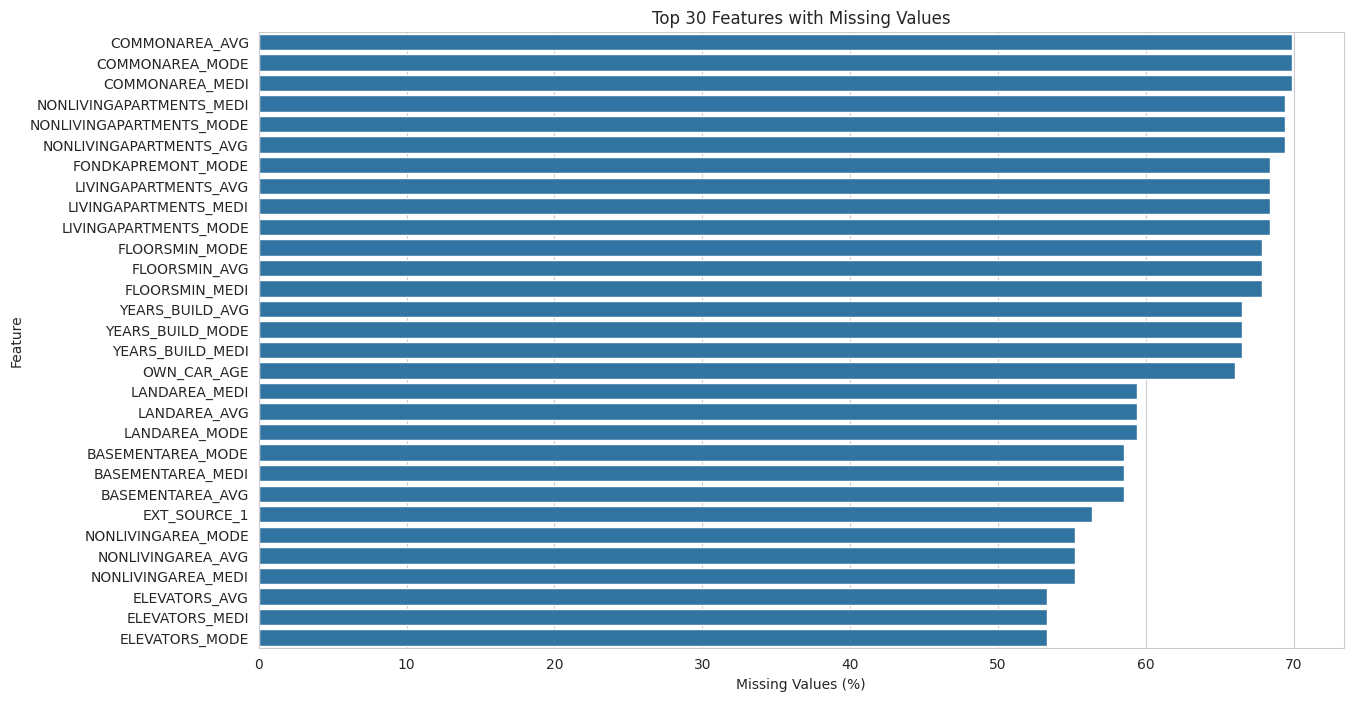

In [7]:
plt.figure(figsize=(14, 8))

missing_top = missing_df.head(30)

sns.barplot(
    data=missing_top,
    x='Missing Percentage',
    y='Column'
)

plt.title('Top 30 Features with Missing Values')
plt.xlabel('Missing Values (%)')
plt.ylabel('Feature')
plt.show()

In [8]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Number of numerical features: 106
Number of categorical features: 16

Numerical Features:
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVI

In [9]:
print("Statistical Summary of Numerical Features:")

display(
    df[numerical_features].describe().T
)

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


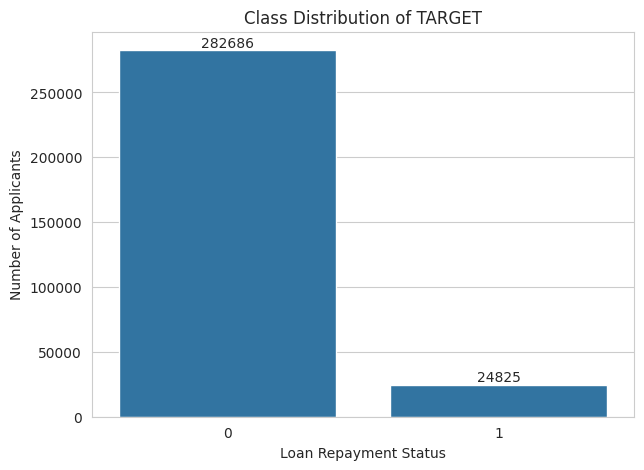

In [10]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='TARGET'
)

plt.title('Class Distribution of TARGET')
plt.xlabel('Loan Repayment Status')
plt.ylabel('Number of Applicants')

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [11]:
target_percentage = df['TARGET'].value_counts(normalize=True) * 100

print("TARGET Distribution (%):")
print(target_percentage)

TARGET Distribution (%):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


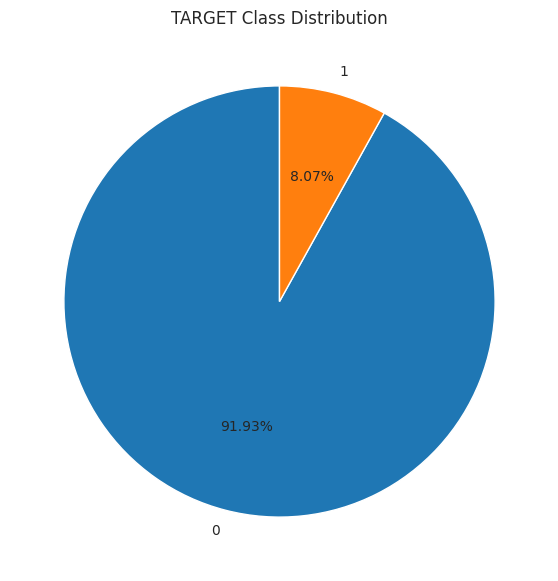

In [12]:
plt.figure(figsize=(7, 7))

df['TARGET'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90
)

plt.title('TARGET Class Distribution')
plt.ylabel('')
plt.show()

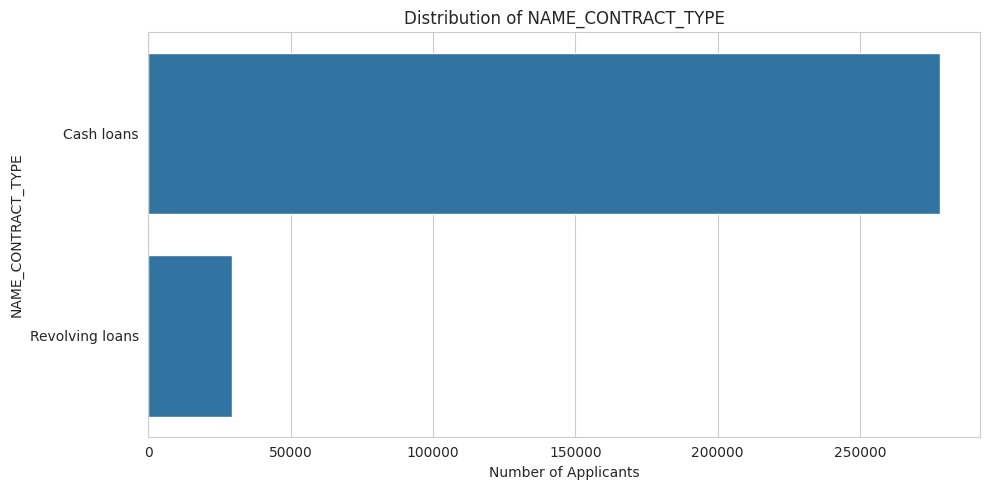

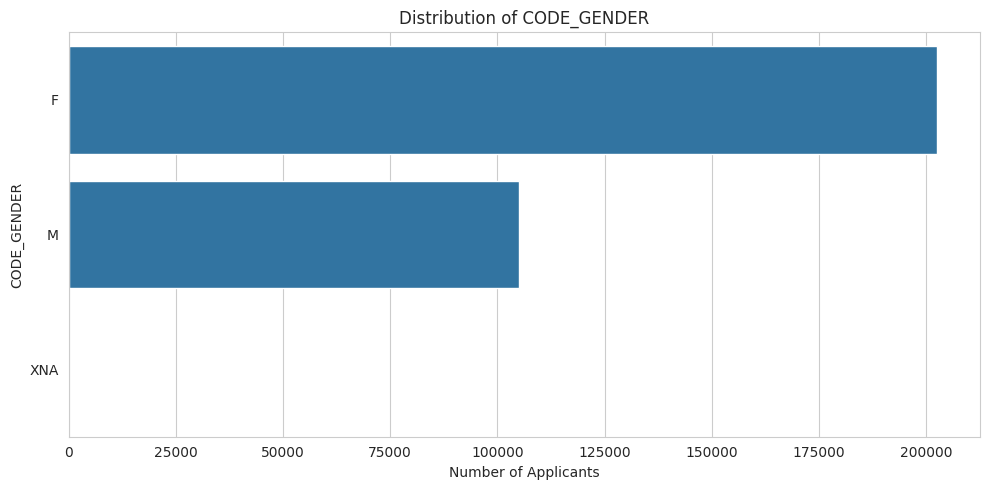

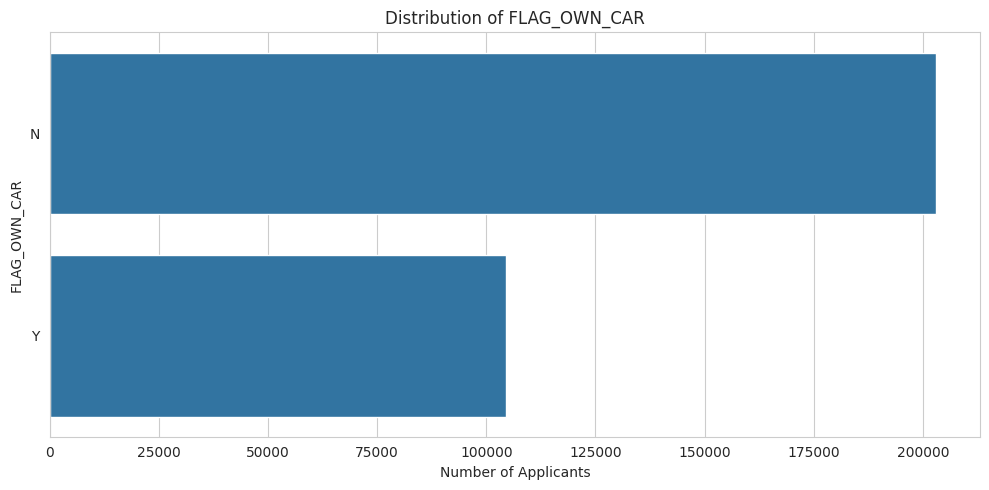

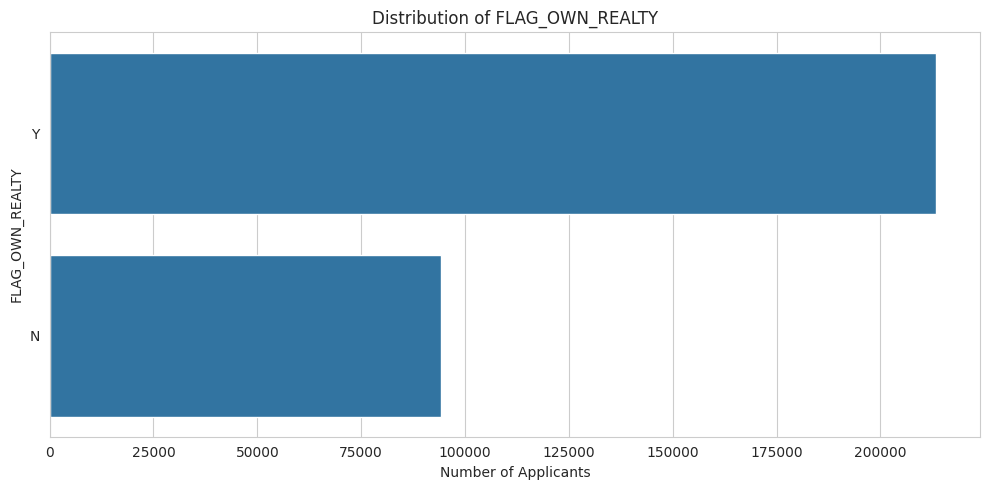

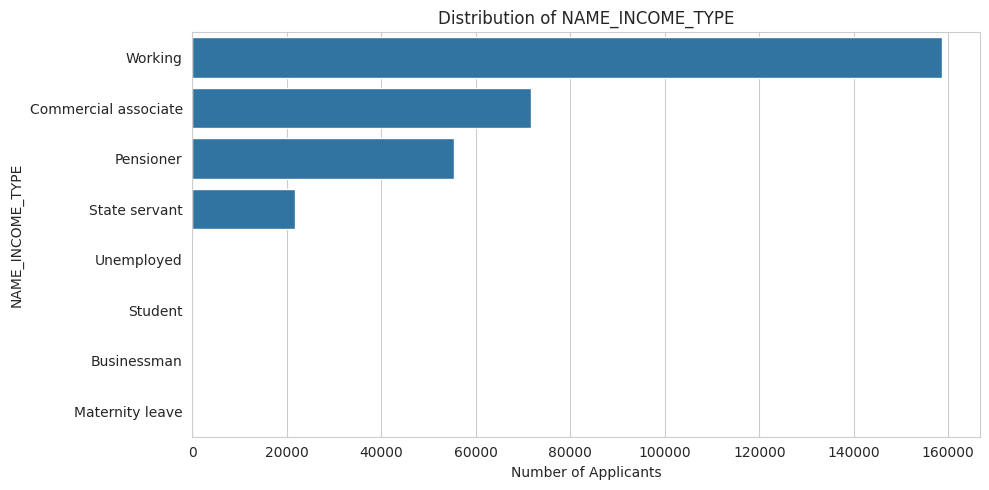

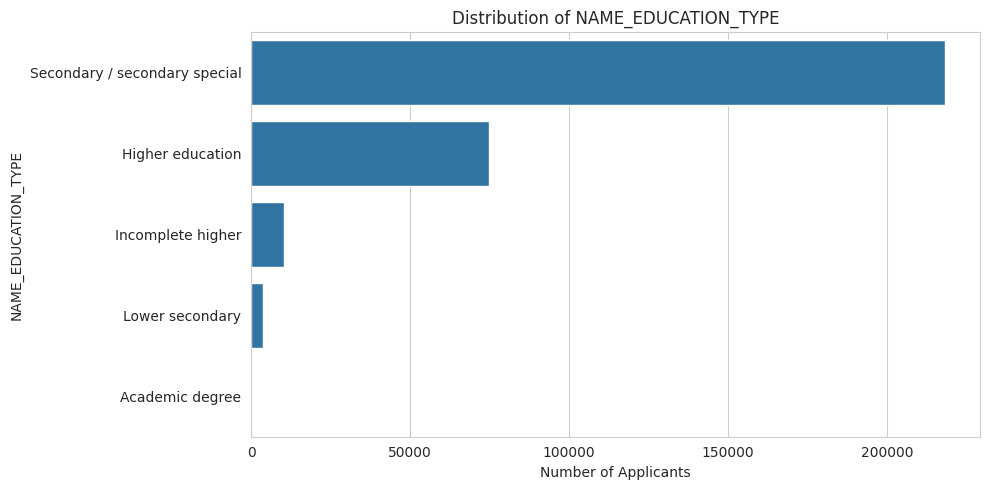

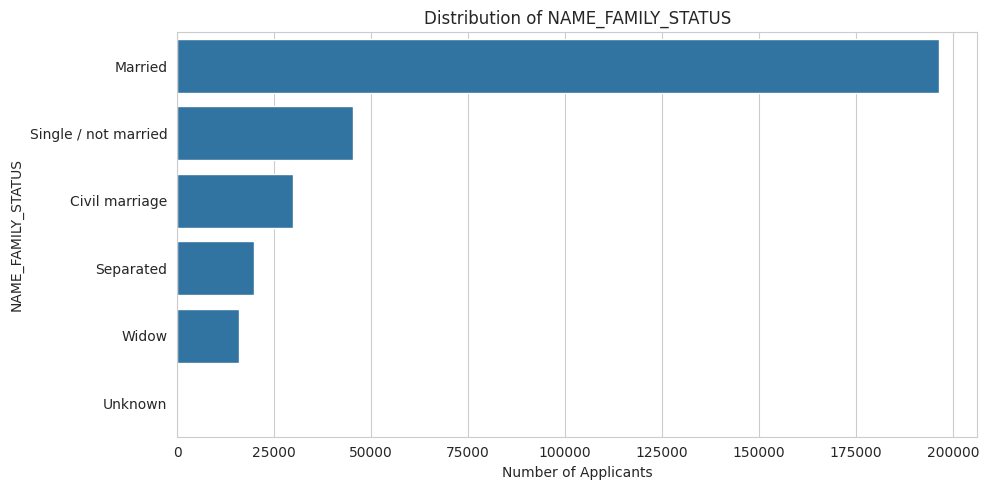

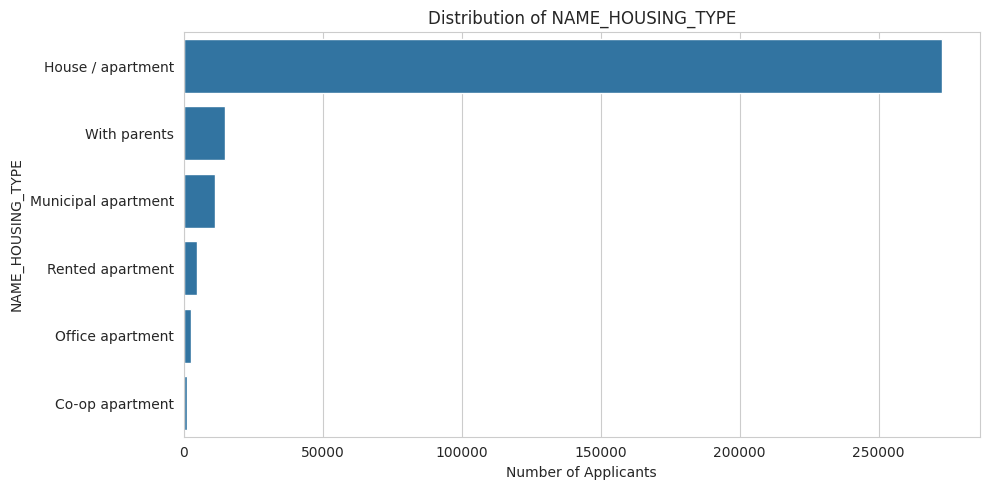

In [13]:
important_categorical = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE'
]

for col in important_categorical:

    if col in df.columns:

        plt.figure(figsize=(10, 5))

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            y=col,
            order=order
        )

        plt.title(f'Distribution of {col}')
        plt.xlabel('Number of Applicants')
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()

<Figure size 1000x500 with 0 Axes>

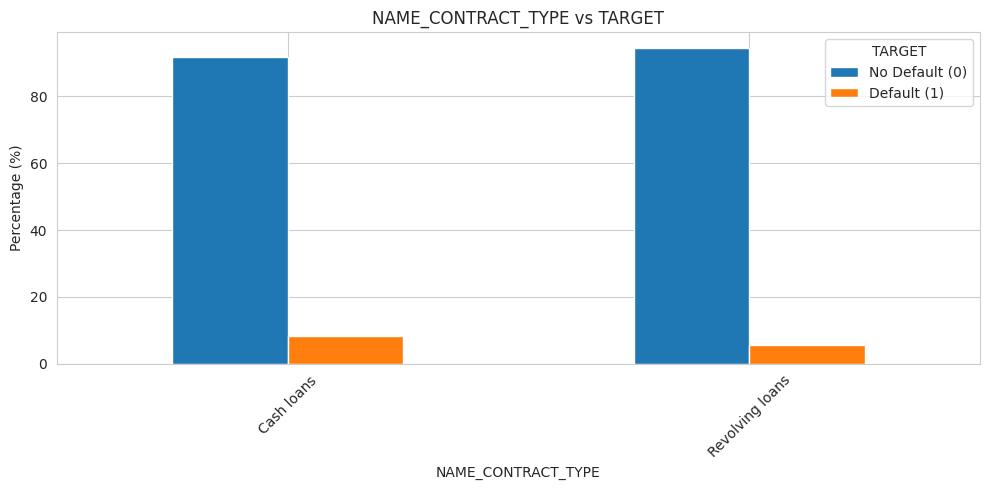

<Figure size 1000x500 with 0 Axes>

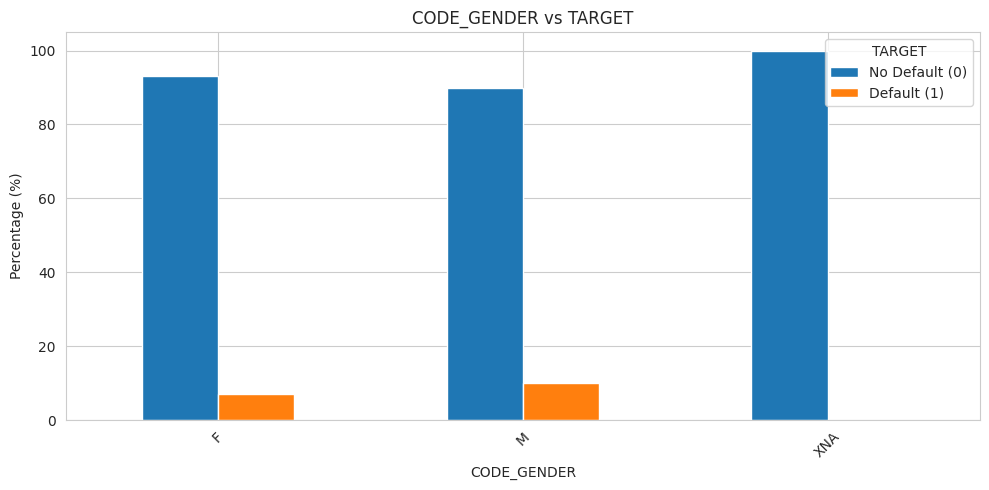

<Figure size 1000x500 with 0 Axes>

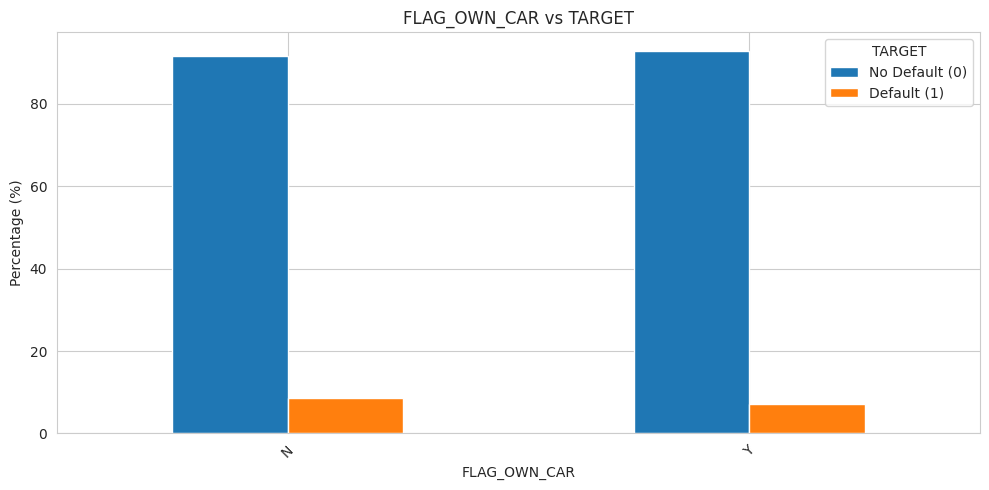

<Figure size 1000x500 with 0 Axes>

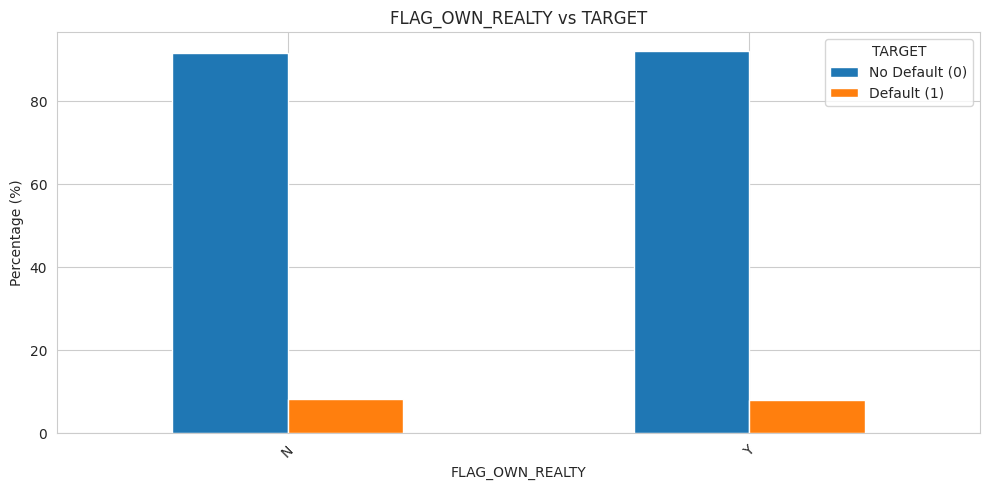

<Figure size 1000x500 with 0 Axes>

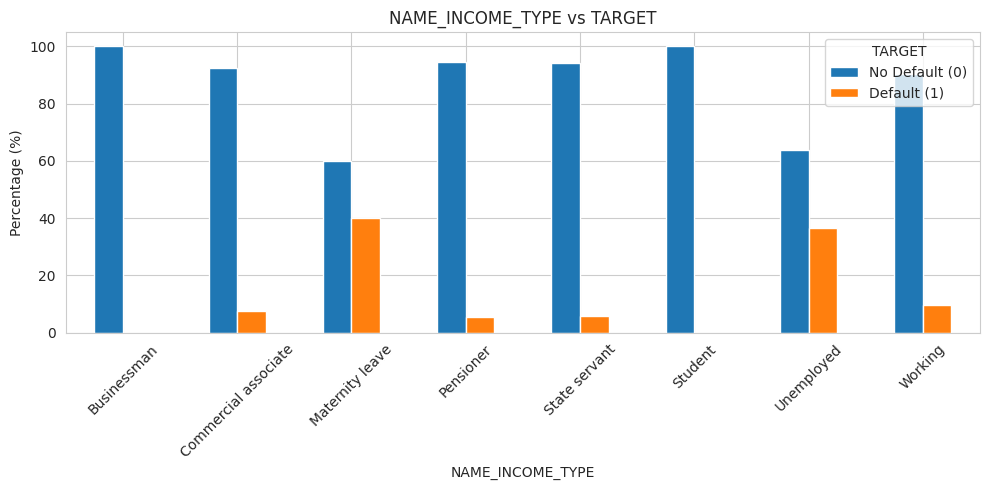

<Figure size 1000x500 with 0 Axes>

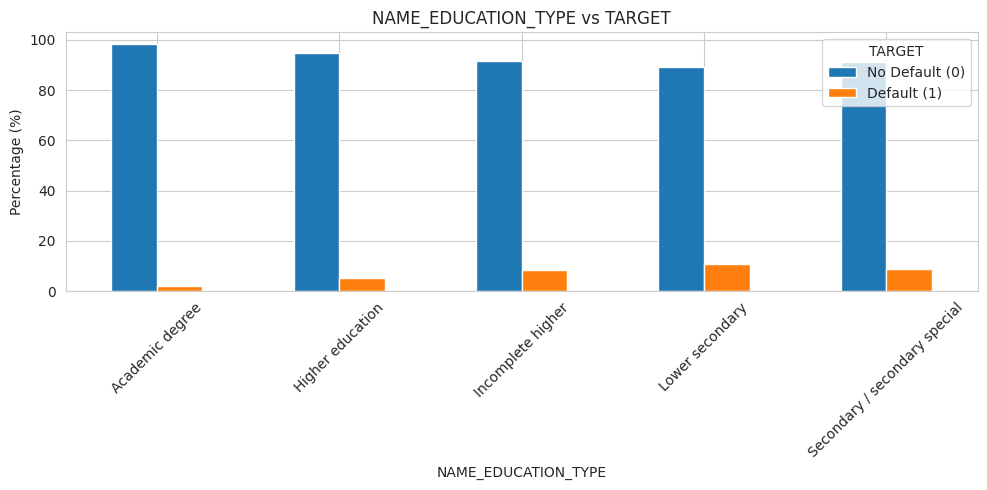

<Figure size 1000x500 with 0 Axes>

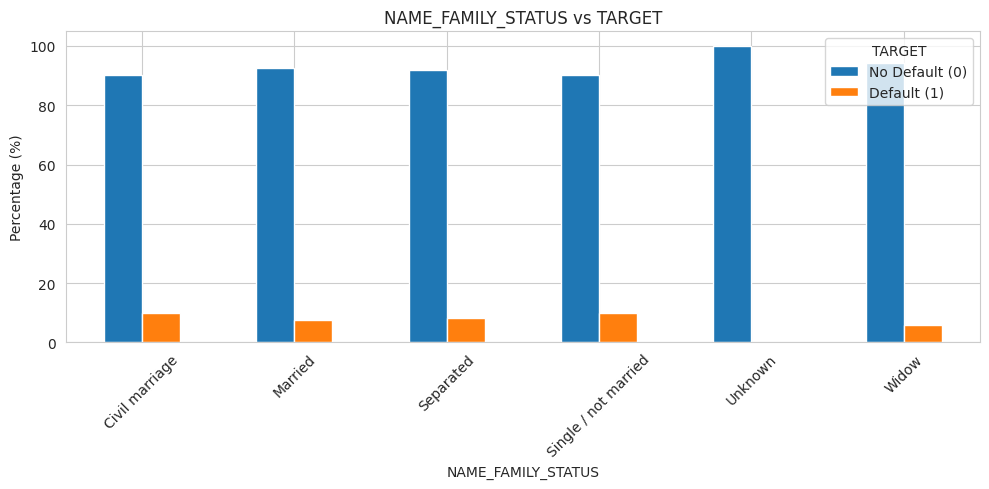

<Figure size 1000x500 with 0 Axes>

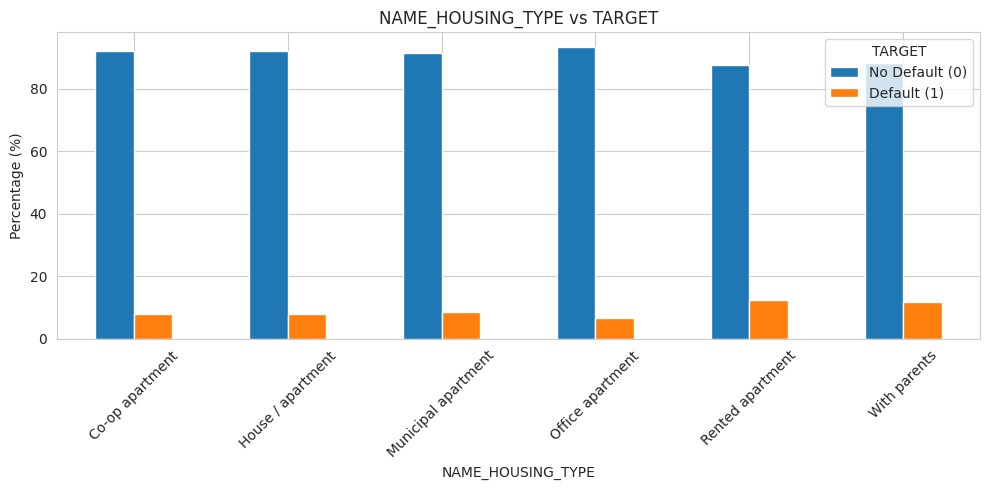

In [14]:
for col in important_categorical:

    if col in df.columns:

        plt.figure(figsize=(10, 5))

        temp = pd.crosstab(
            df[col],
            df['TARGET'],
            normalize='index'
        ) * 100

        temp.plot(
            kind='bar',
            figsize=(10, 5)
        )

        plt.title(f'{col} vs TARGET')
        plt.xlabel(col)
        plt.ylabel('Percentage (%)')
        plt.xticks(rotation=45)

        plt.legend(
            title='TARGET',
            labels=['No Default (0)', 'Default (1)']
        )

        plt.tight_layout()
        plt.show()

In [15]:
important_numerical = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'REGION_POPULATION_RELATIVE',
    'OWN_CAR_AGE',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

important_numerical = [
    col for col in important_numerical
    if col in df.columns
]

print(important_numerical)

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'REGION_POPULATION_RELATIVE', 'OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


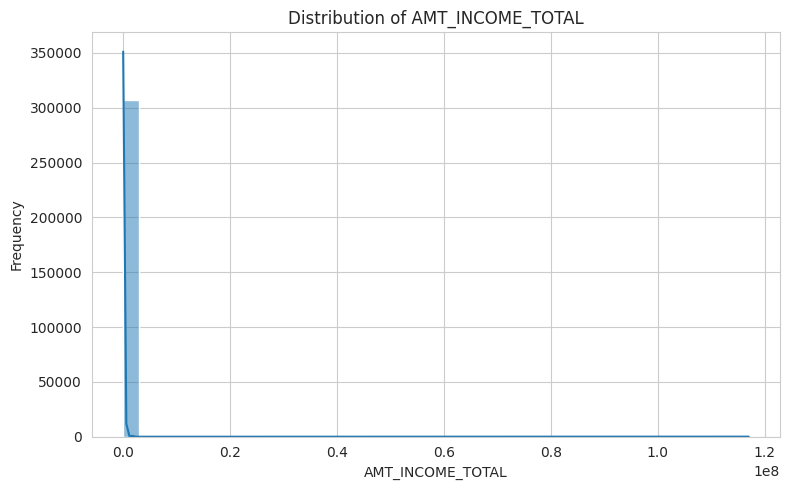

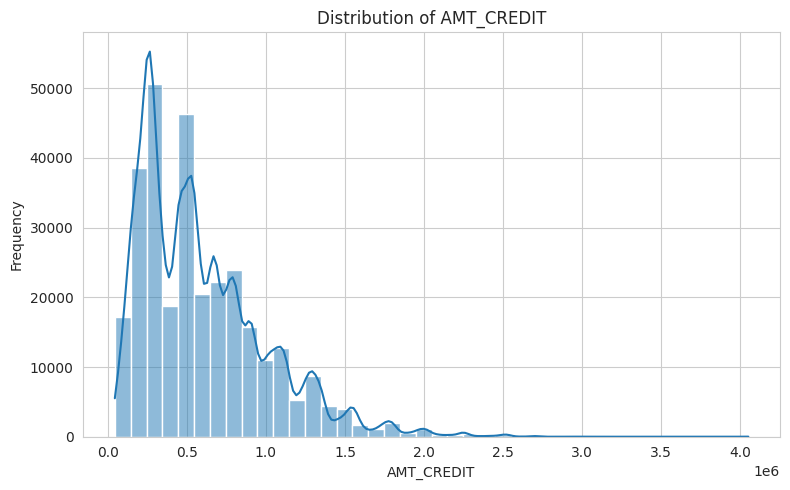

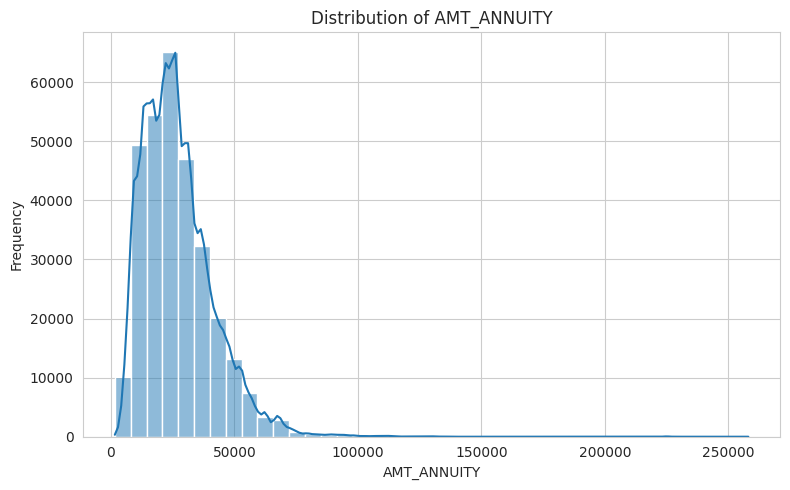

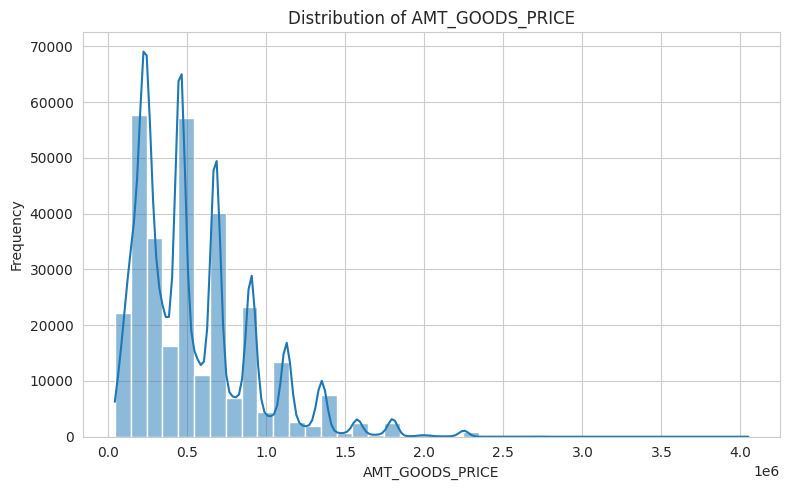

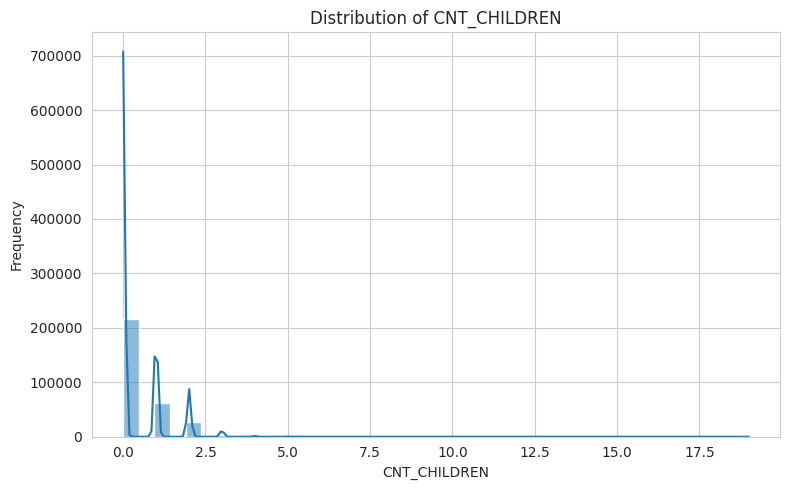

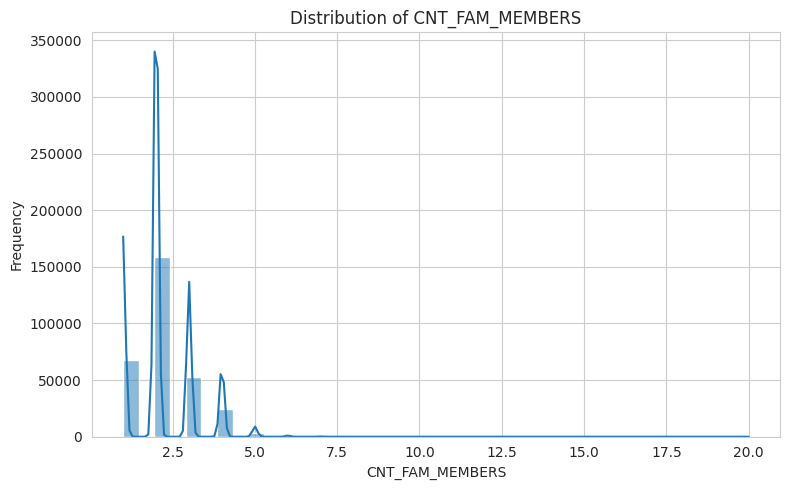

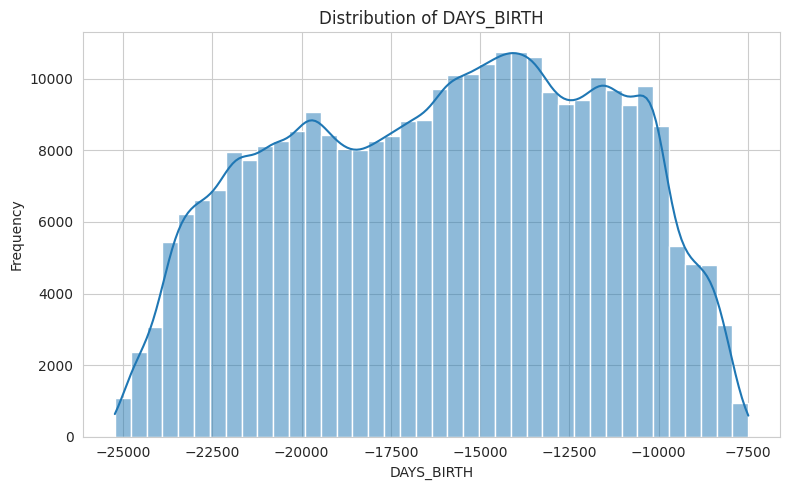

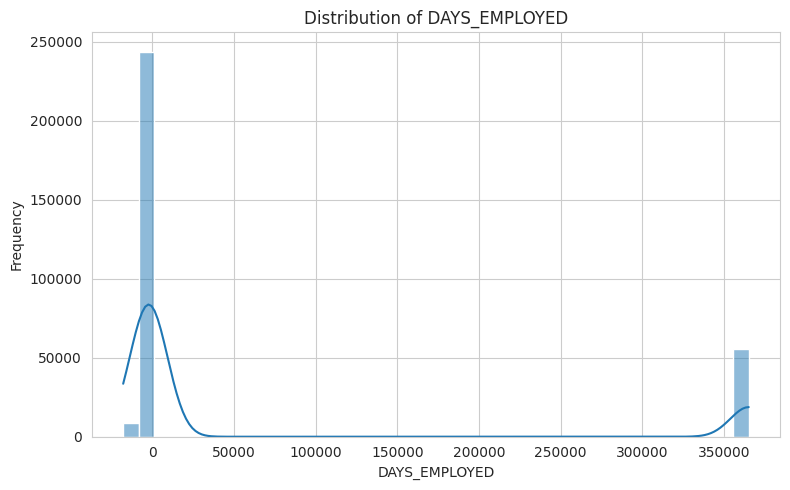

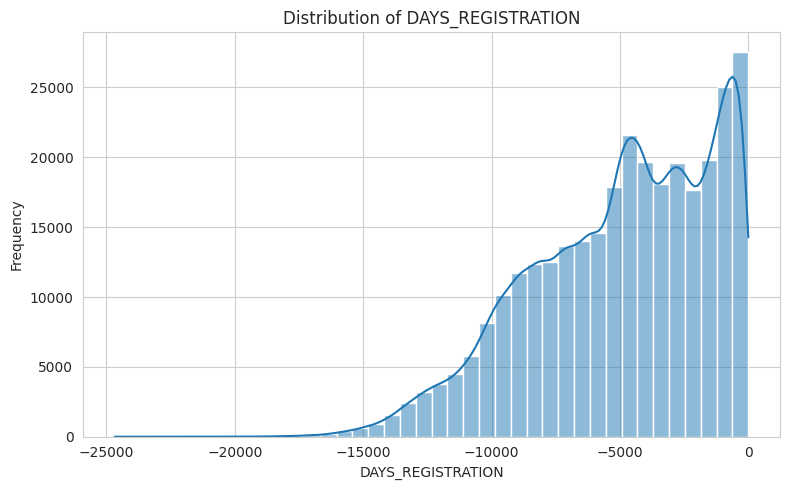

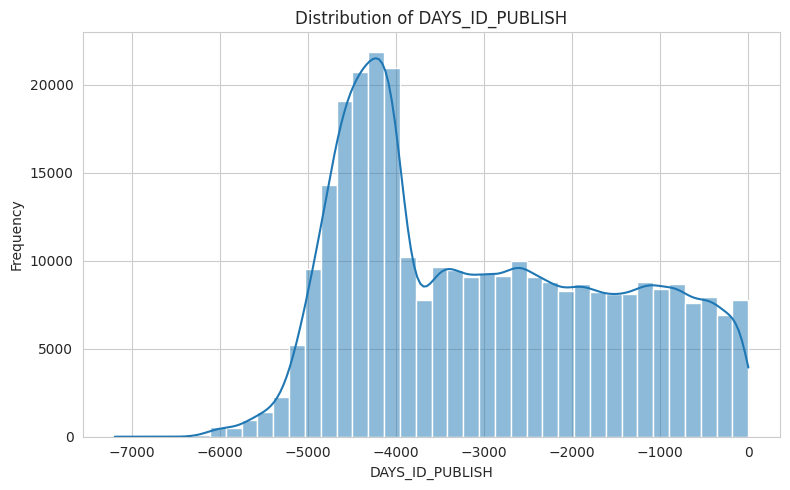

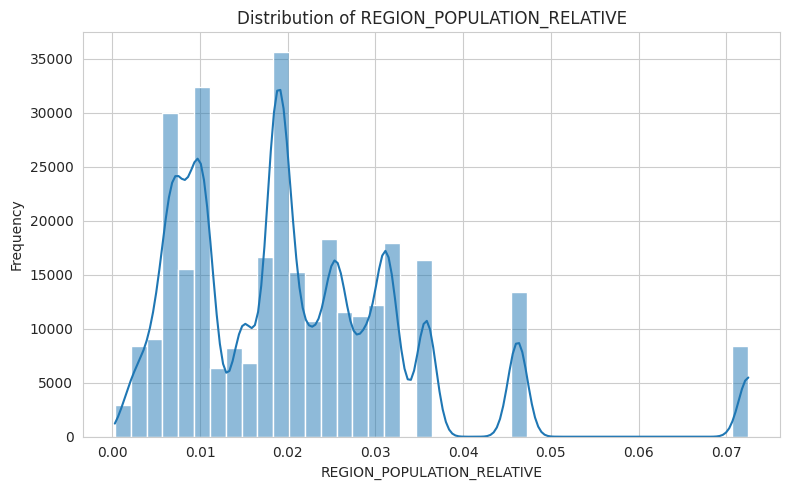

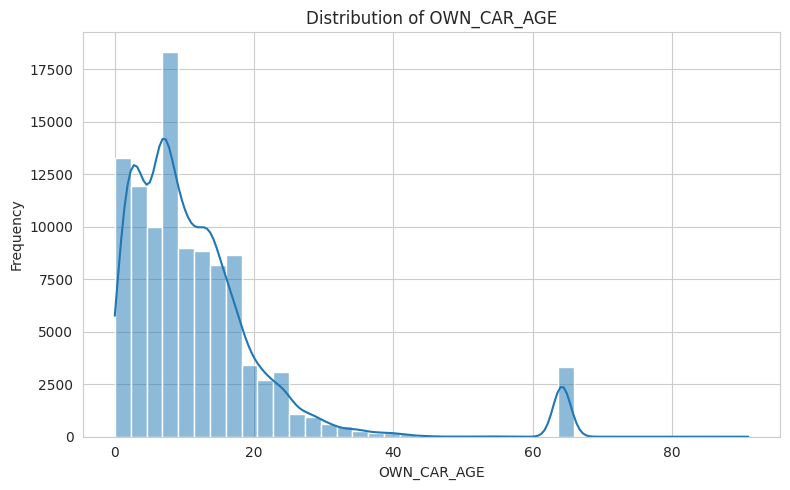

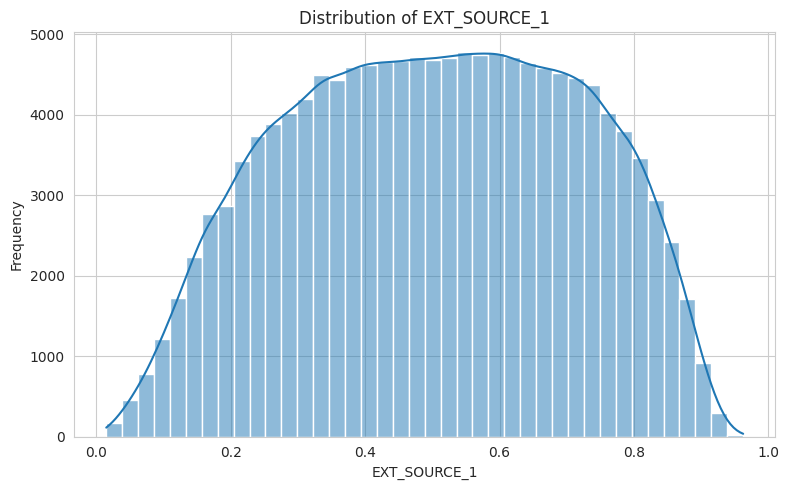

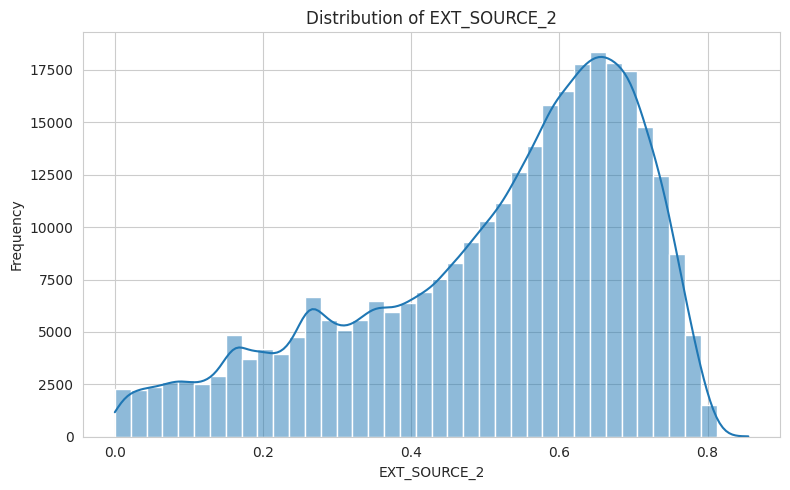

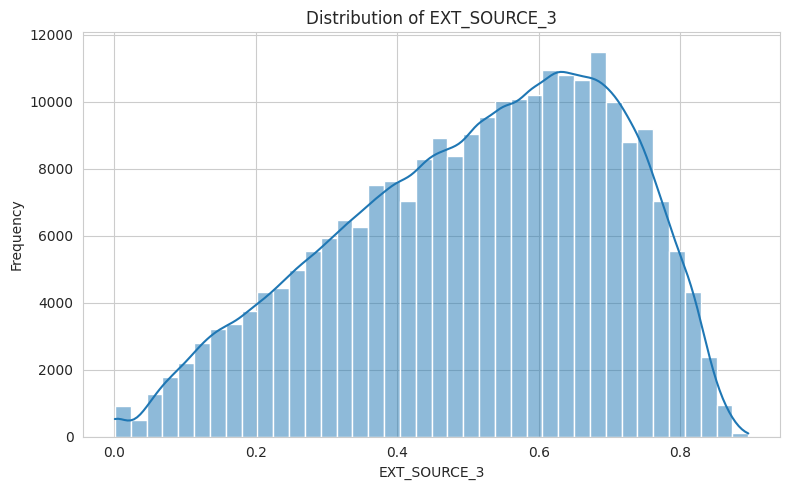

In [16]:
for col in important_numerical:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

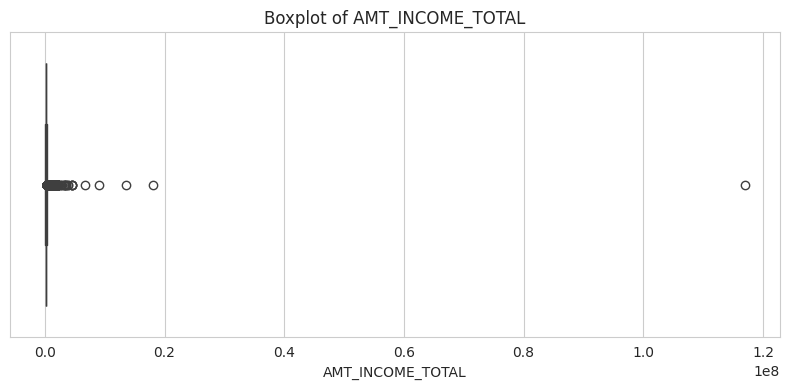

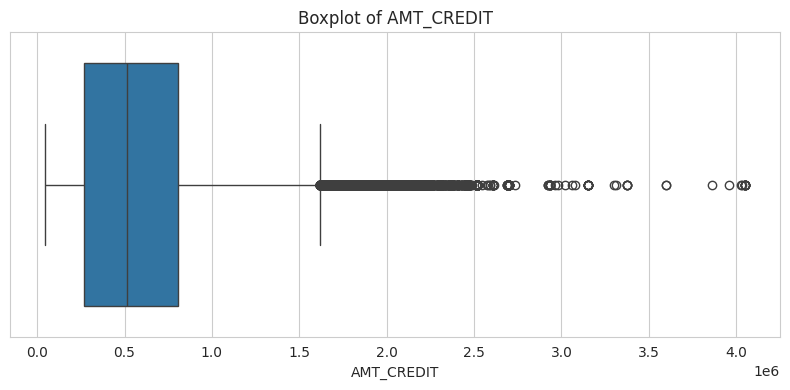

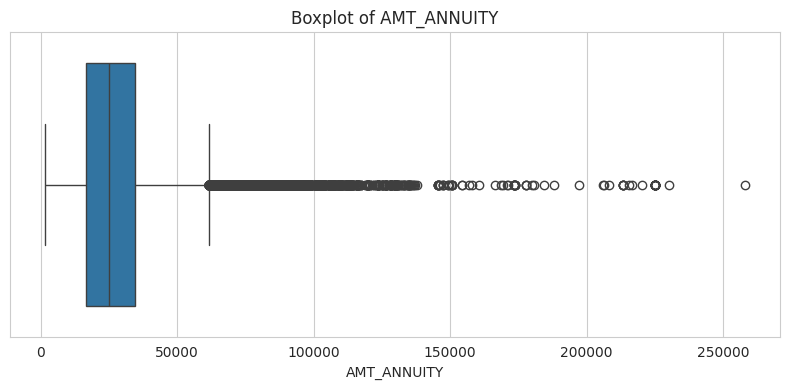

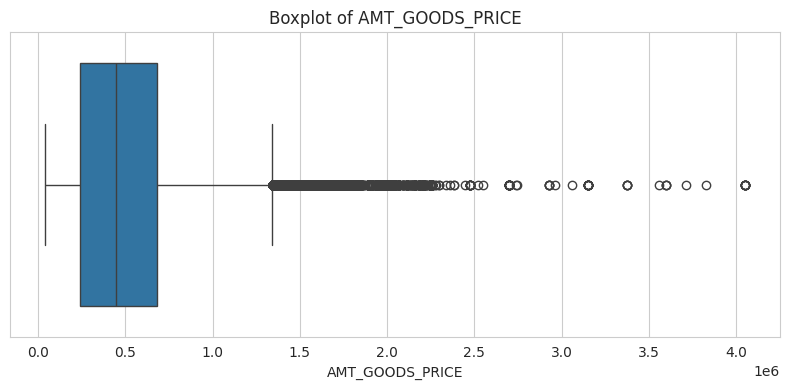

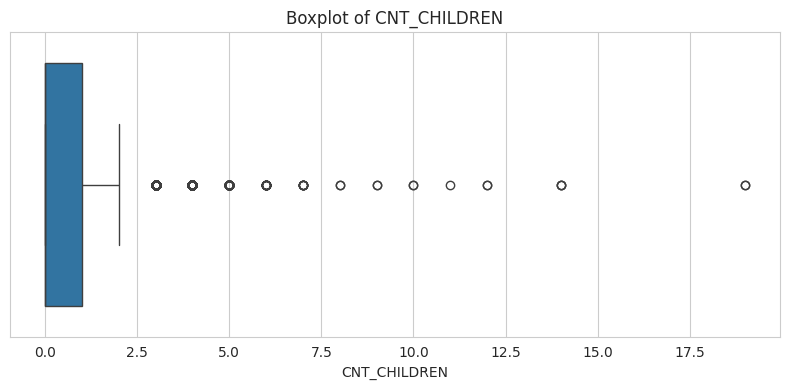

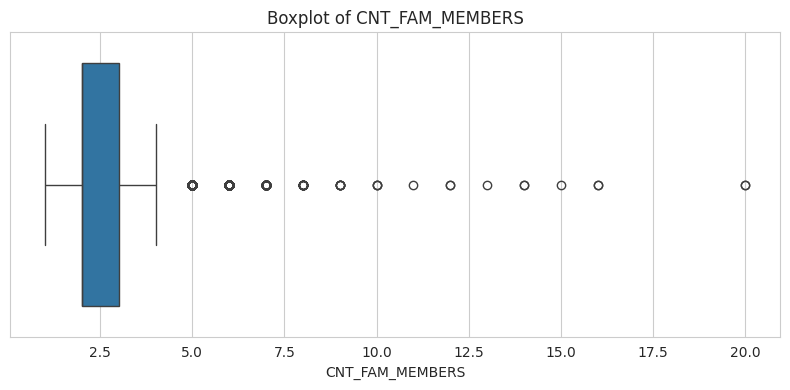

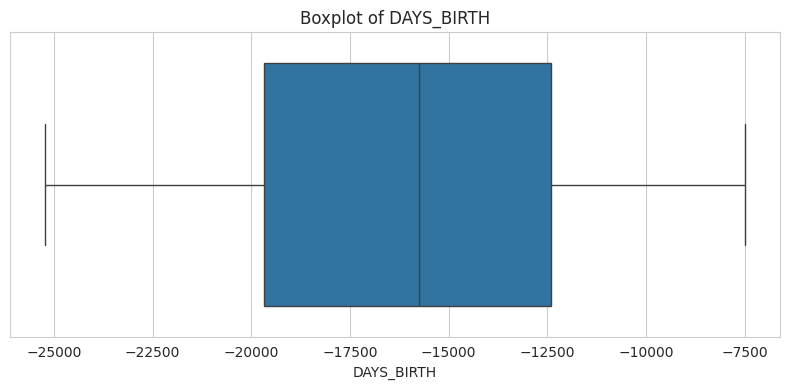

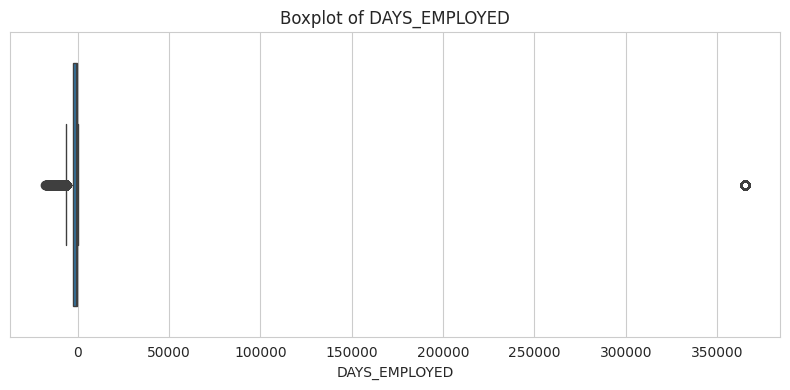

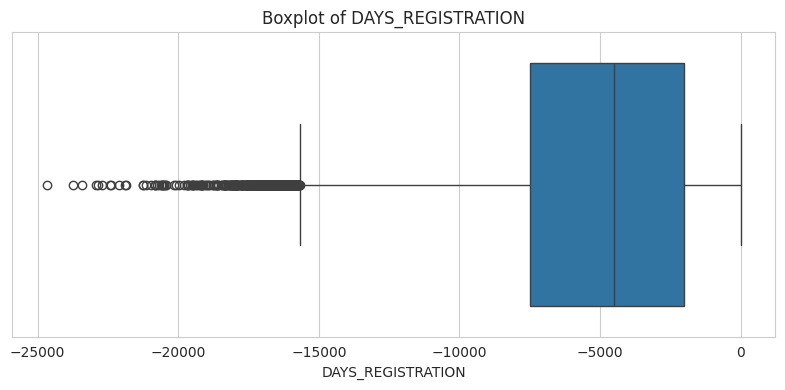

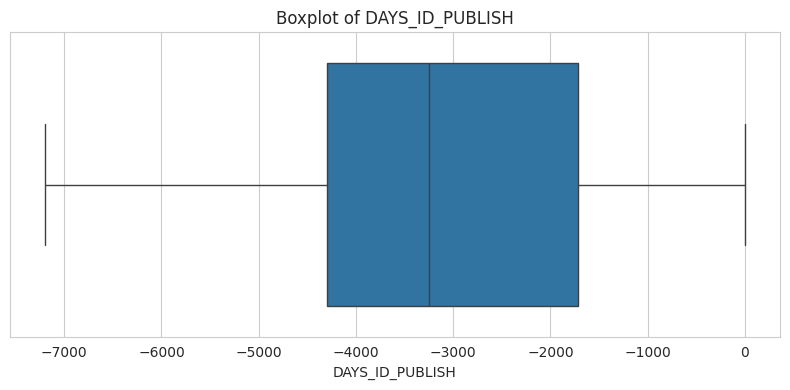

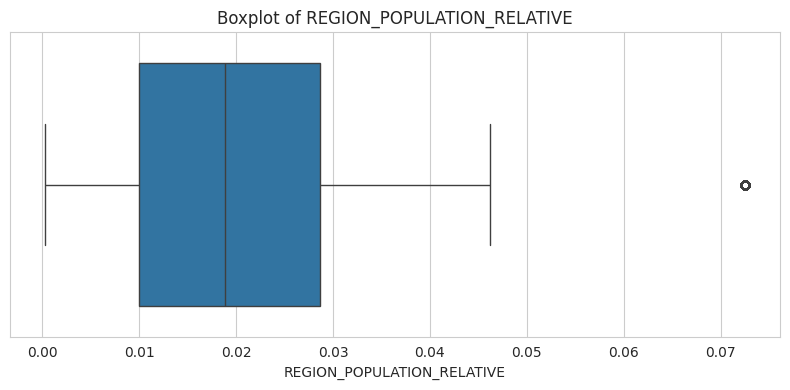

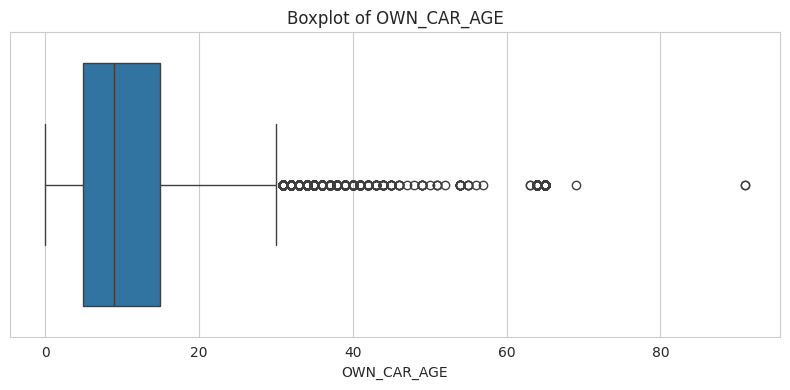

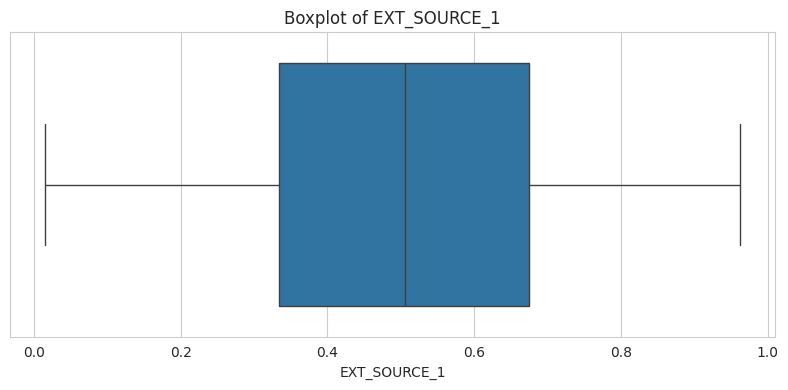

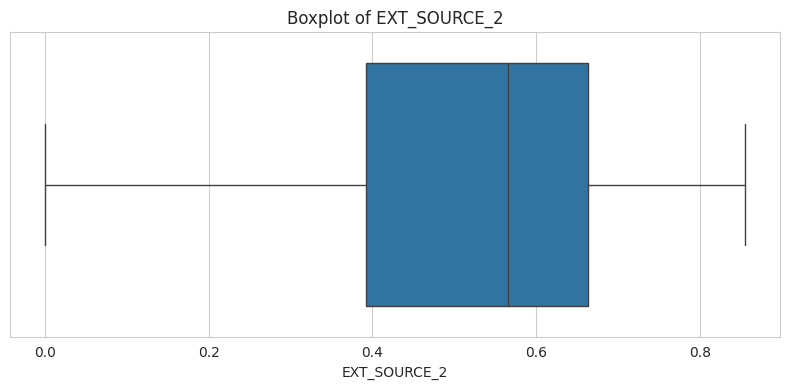

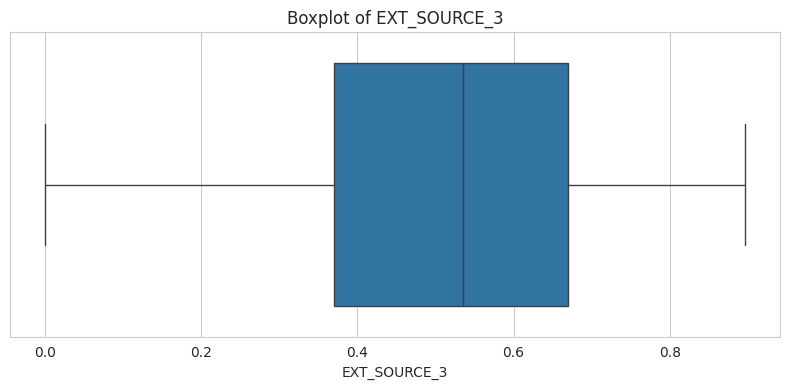

In [17]:
for col in important_numerical:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

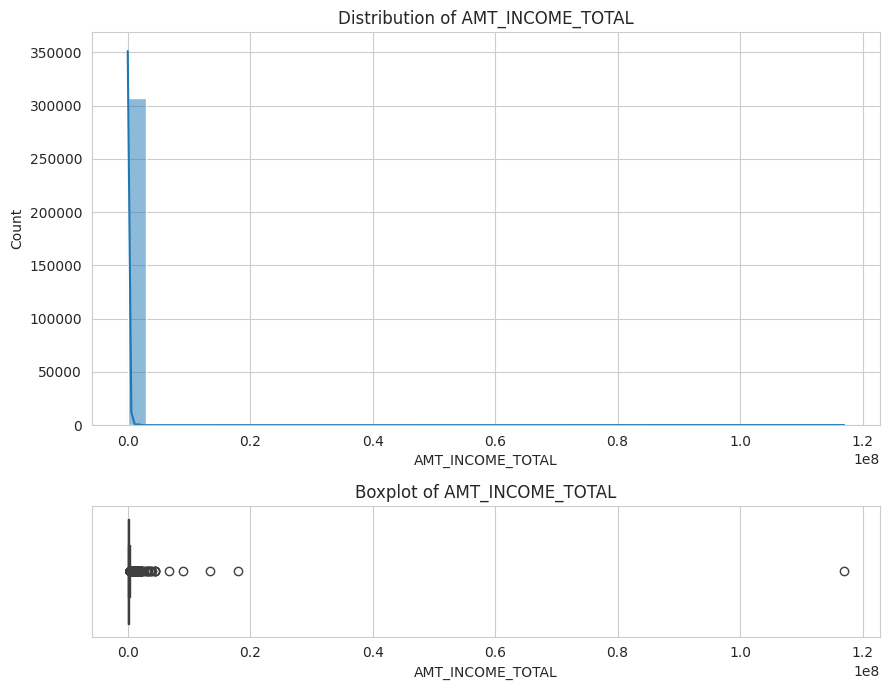

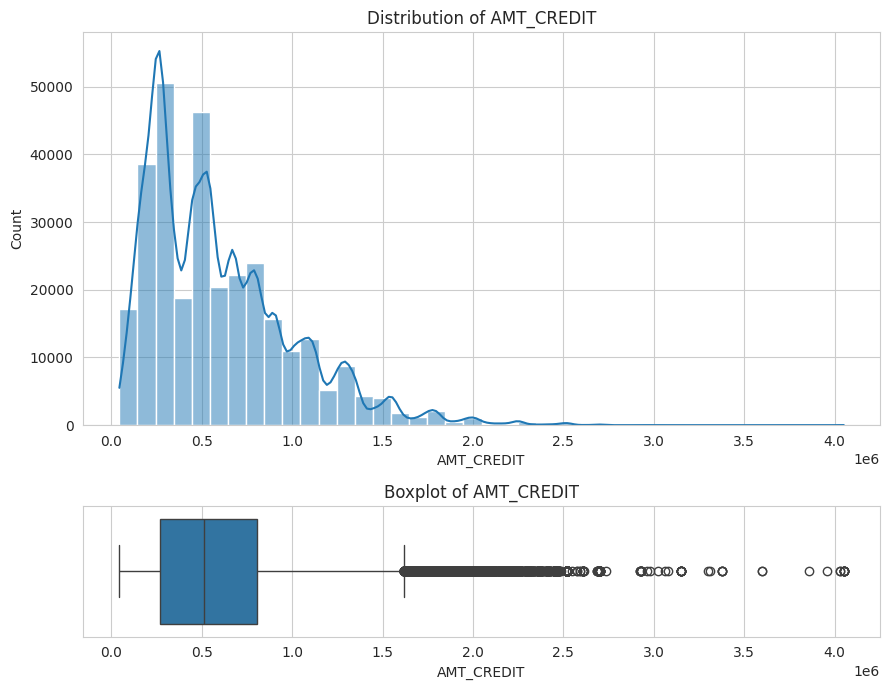

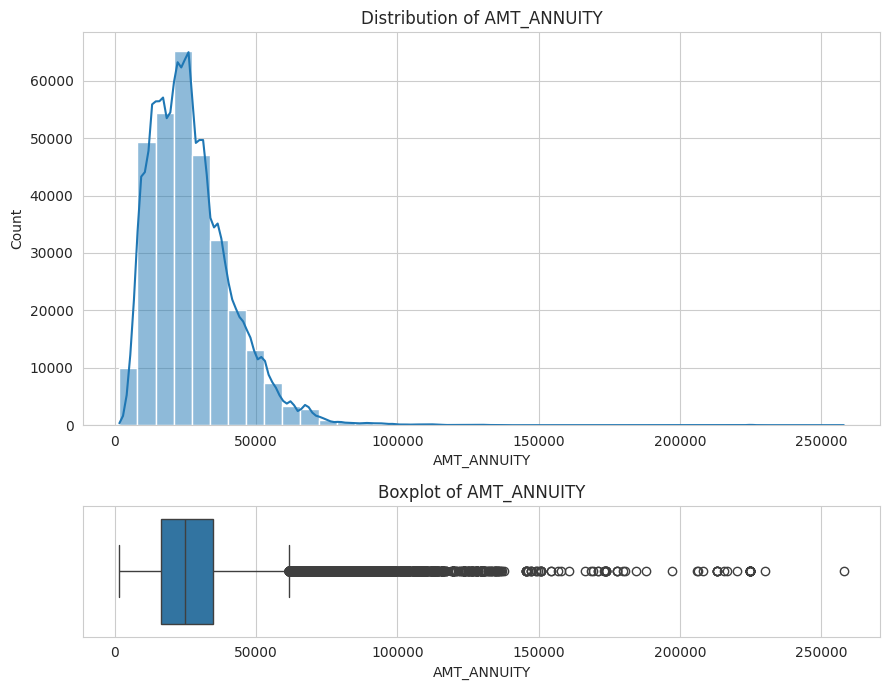

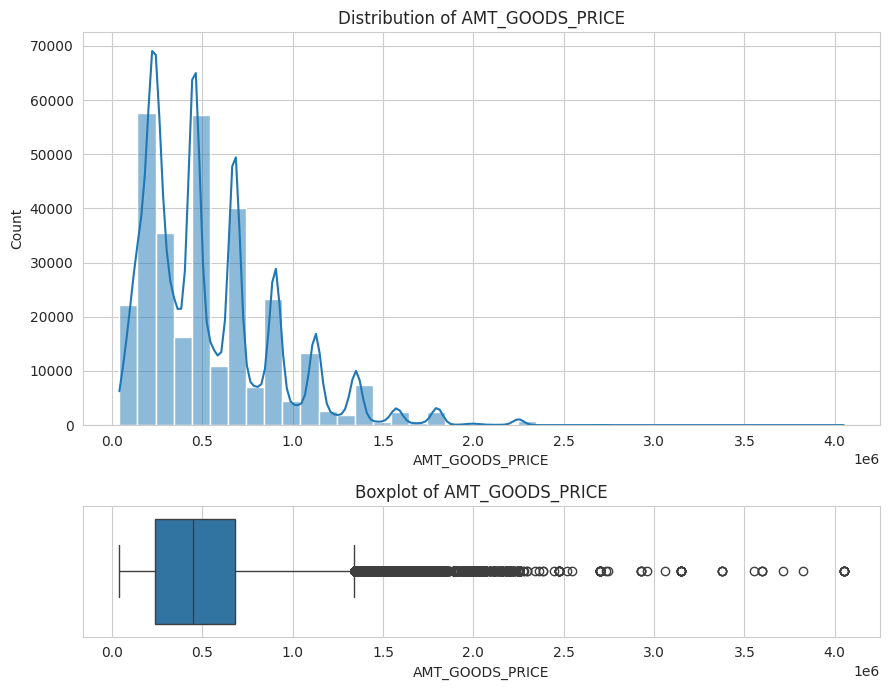

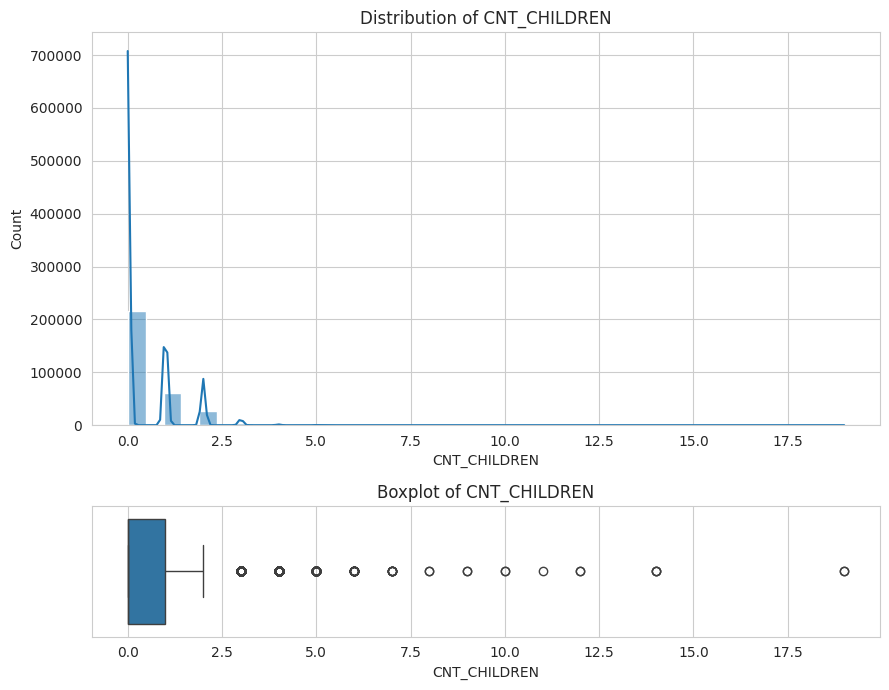

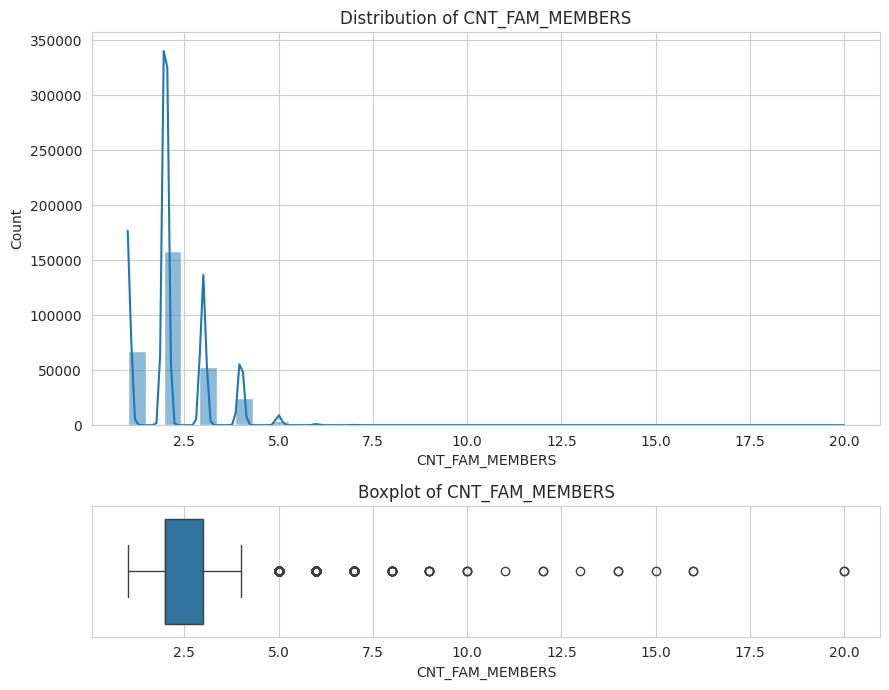

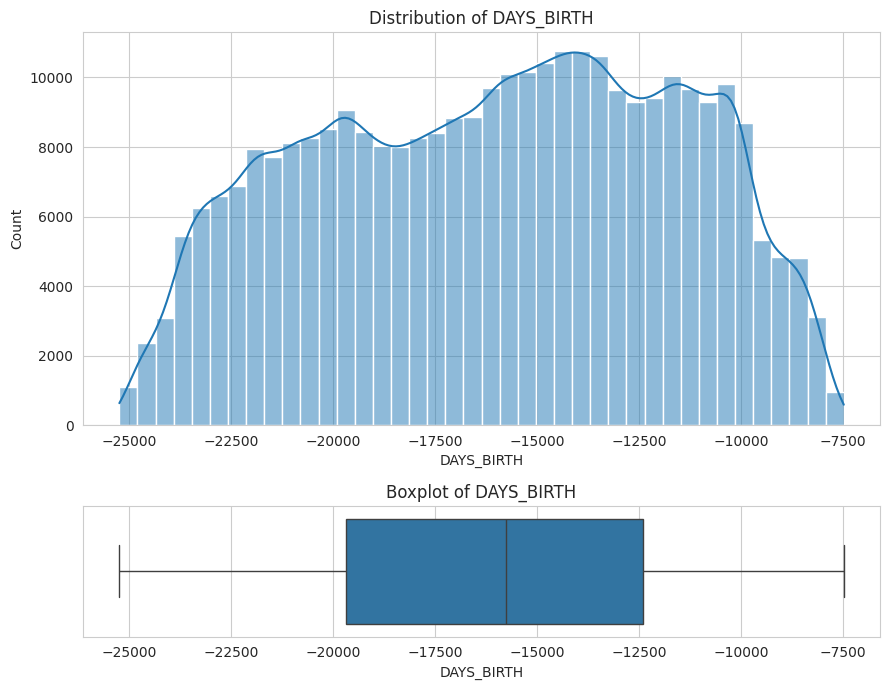

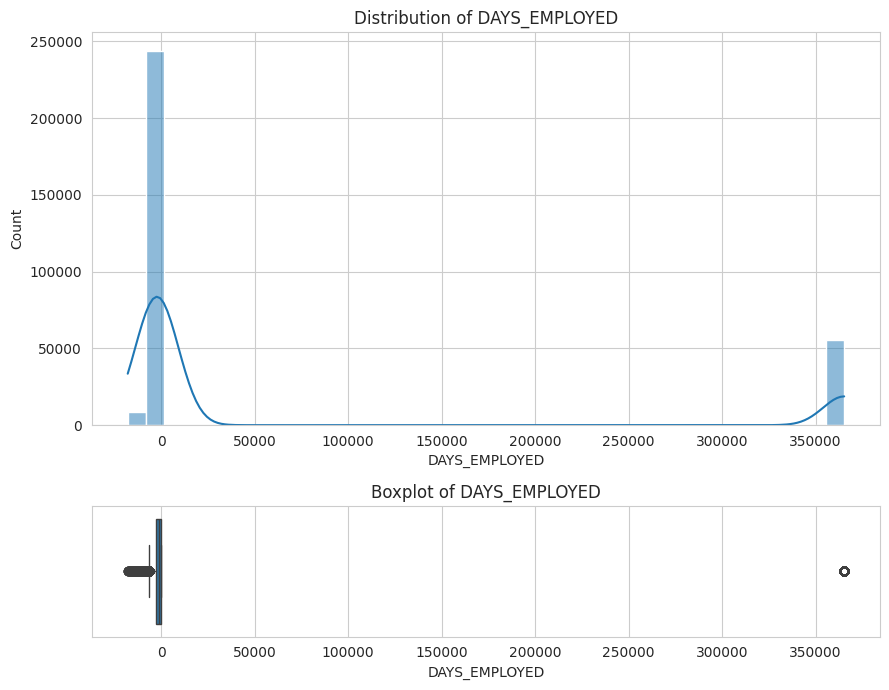

In [18]:
for col in important_numerical[:8]:

    fig, axes = plt.subplots(
        2, 1,
        figsize=(9, 7),
        gridspec_kw={'height_ratios': [3, 1]}
    )

    sns.histplot(
        df[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f'Distribution of {col}')

    sns.boxplot(
        x=df[col],
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [19]:
summary = pd.DataFrame({
    'Mean': df[important_numerical].mean(),
    'Median': df[important_numerical].median(),
    'Std Dev': df[important_numerical].std(),
    'Minimum': df[important_numerical].min(),
    'Maximum': df[important_numerical].max()
})

display(summary)

,Mean,Median,Std Dev,Minimum,Maximum
AMT_INCOME_TOTAL,168797.919297,147150.000000,237123.146279,2.565000e+04,1.170000e+08
AMT_CREDIT,599025.999706,513531.000000,402490.776996,4.500000e+04,4.050000e+06
AMT_ANNUITY,27108.573909,24903.000000,14493.737315,1.615500e+03,2.580255e+05
AMT_GOODS_PRICE,538396.207429,450000.000000,369446.460540,4.050000e+04,4.050000e+06
CNT_CHILDREN,0.417052,0.000000,0.722121,0.000000e+00,1.900000e+01
CNT_FAM_MEMBERS,2.152665,2.000000,0.910682,1.000000e+00,2.000000e+01
DAYS_BIRTH,-16036.995067,-15750.000000,4363.988632,-2.522900e+04,-7.489000e+03
DAYS_EMPLOYED,63815.045904,-1213.000000,141275.766519,-1.791200e+04,3.652430e+05
DAYS_REGISTRATION,-4986.120328,-4504.000000,3522.886321,-2.467200e+04,0.000000e+00
DAYS_ID_PUBLISH,-2994.202373,-3254.000000,1509.450419,-7.197000e+03,0.000000e+00


In [20]:
skewness = df[important_numerical].skew()

skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
}).sort_values(
    by='Skewness',
    ascending=False
)

display(skew_df)

,Feature,Skewness
0,AMT_INCOME_TOTAL,391.559654
11,OWN_CAR_AGE,2.745422
4,CNT_CHILDREN,1.974604
7,DAYS_EMPLOYED,1.664346
2,AMT_ANNUITY,1.579777
10,REGION_POPULATION_RELATIVE,1.488009
3,AMT_GOODS_PRICE,1.349000
1,AMT_CREDIT,1.234778
5,CNT_FAM_MEMBERS,0.987543
9,DAYS_ID_PUBLISH,0.349327


In [21]:
for feature in skew_df['Feature']:

    value = skew_df.loc[
        skew_df['Feature'] == feature,
        'Skewness'
    ].values[0]

    if abs(value) < 0.5:
        interpretation = "Approximately symmetric"

    elif abs(value) < 1:
        interpretation = "Moderately skewed"

    else:
        interpretation = "Highly skewed"

    print(f"{feature}: {value:.3f} → {interpretation}")

AMT_INCOME_TOTAL: 391.560 → Highly skewed
OWN_CAR_AGE: 2.745 → Highly skewed
CNT_CHILDREN: 1.975 → Highly skewed
DAYS_EMPLOYED: 1.664 → Highly skewed
AMT_ANNUITY: 1.580 → Highly skewed
REGION_POPULATION_RELATIVE: 1.488 → Highly skewed
AMT_GOODS_PRICE: 1.349 → Highly skewed
AMT_CREDIT: 1.235 → Highly skewed
CNT_FAM_MEMBERS: 0.988 → Moderately skewed
DAYS_ID_PUBLISH: 0.349 → Approximately symmetric
EXT_SOURCE_1: -0.069 → Approximately symmetric
DAYS_BIRTH: -0.116 → Approximately symmetric
EXT_SOURCE_3: -0.409 → Approximately symmetric
DAYS_REGISTRATION: -0.591 → Moderately skewed
EXT_SOURCE_2: -0.794 → Moderately skewed


In [22]:
outlier_results = []

for col in important_numerical:

    data = df[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    outlier_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage':
            (len(outliers) / len(data)) * 100
    })

outlier_df = pd.DataFrame(outlier_results)

display(
    outlier_df.sort_values(
        by='Outlier Percentage',
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
7,DAYS_EMPLOYED,-2760.000000,-289.000000,2471.000000,-6466.500000,3.417500e+03,72217,23.484363
3,AMT_GOODS_PRICE,238500.000000,679500.000000,441000.000000,-423000.000000,1.341000e+06,14728,4.793756
11,OWN_CAR_AGE,5.000000,15.000000,10.000000,-10.000000,3.000000e+01,4932,4.715917
0,AMT_INCOME_TOTAL,112500.000000,202500.000000,90000.000000,-22500.000000,3.375000e+05,14035,4.564064
10,REGION_POPULATION_RELATIVE,0.010006,0.028663,0.018657,-0.017980,5.664850e-02,8412,2.735512
2,AMT_ANNUITY,16524.000000,34596.000000,18072.000000,-10584.000000,6.170400e+04,7504,2.440333
1,AMT_CREDIT,270000.000000,808650.000000,538650.000000,-537975.000000,1.616625e+06,6562,2.133907
4,CNT_CHILDREN,0.000000,1.000000,1.000000,-1.500000,2.500000e+00,4272,1.389219
5,CNT_FAM_MEMBERS,2.000000,3.000000,1.000000,0.500000,4.500000e+00,4007,1.303051
8,DAYS_REGISTRATION,-7479.500000,-2010.000000,5469.500000,-15683.750000,6.194250e+03,659,0.214301


In [23]:
correlation_data = df[numerical_features].copy()

correlation_matrix = correlation_data.corr()

In [24]:
target_corr = correlation_matrix['TARGET'].sort_values(
    key=abs,
    ascending=False
)

print("Features most correlated with TARGET:")

display(target_corr.head(20))

Features most correlated with TARGET:


,TARGET
TARGET,1.000000
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994


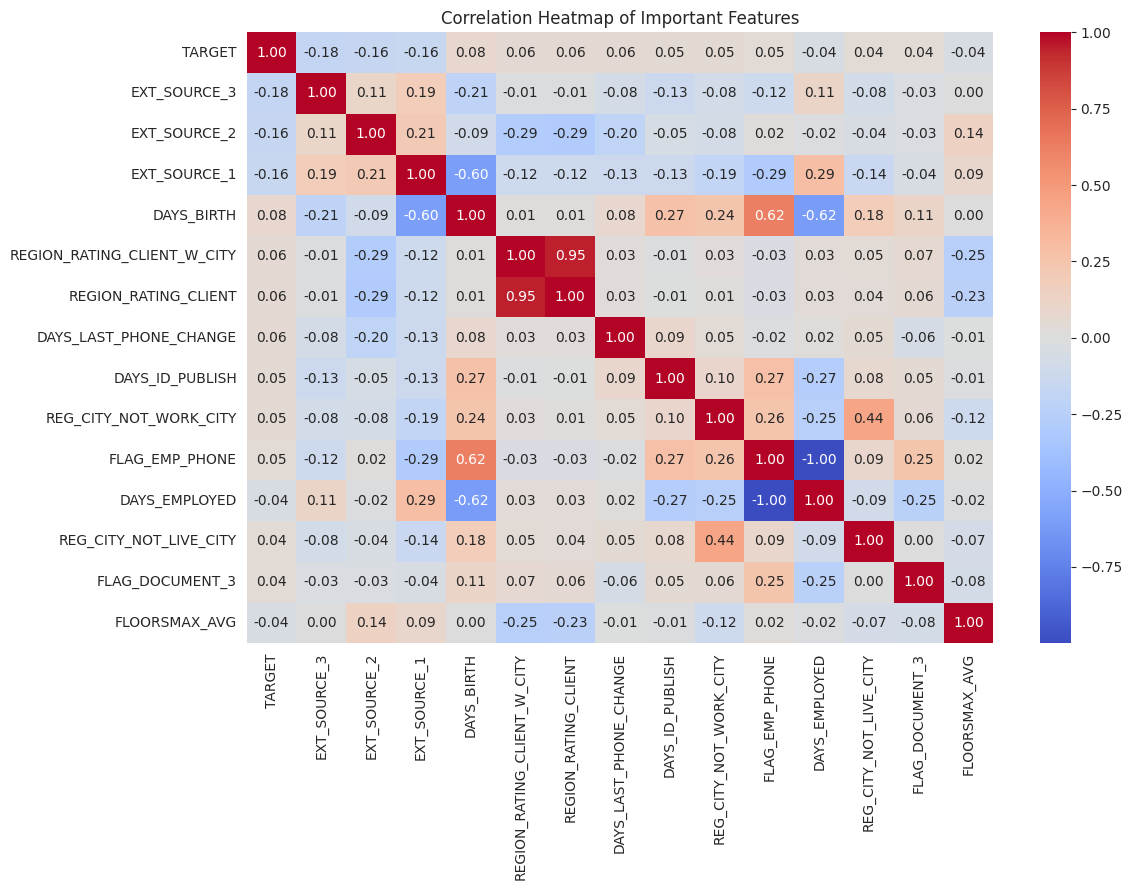

In [25]:
top_corr_features = target_corr.head(15).index

plt.figure(figsize=(12, 9))

sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Important Features')
plt.tight_layout()
plt.show()

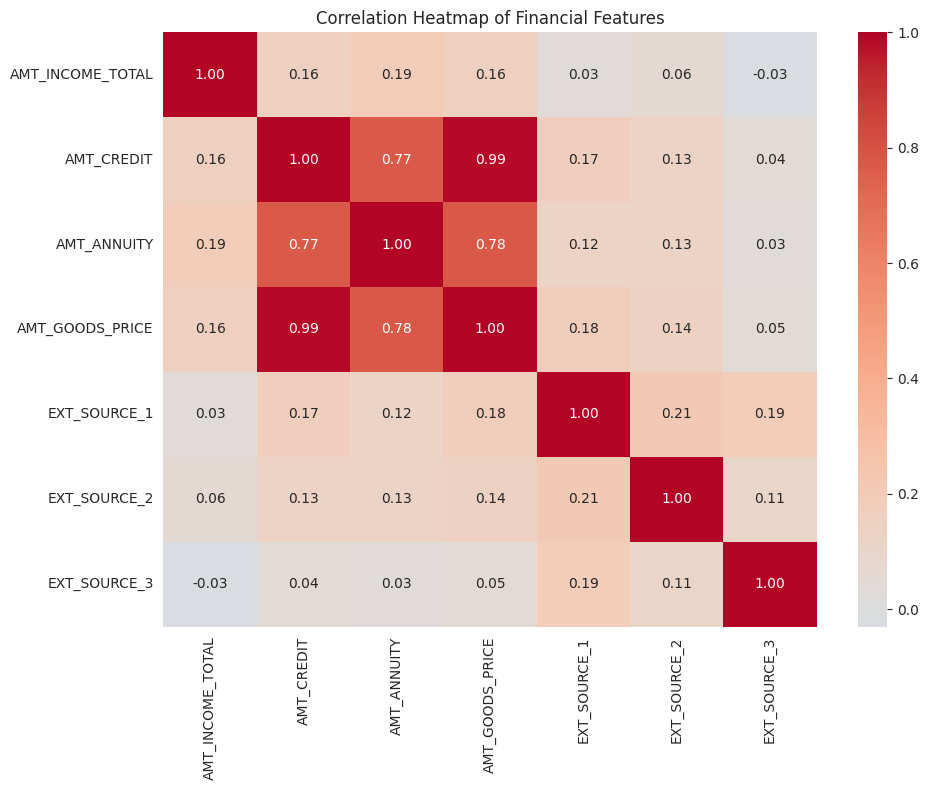

In [26]:
financial_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

financial_features = [
    col for col in financial_features
    if col in df.columns
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[financial_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Financial Features')
plt.tight_layout()
plt.show()

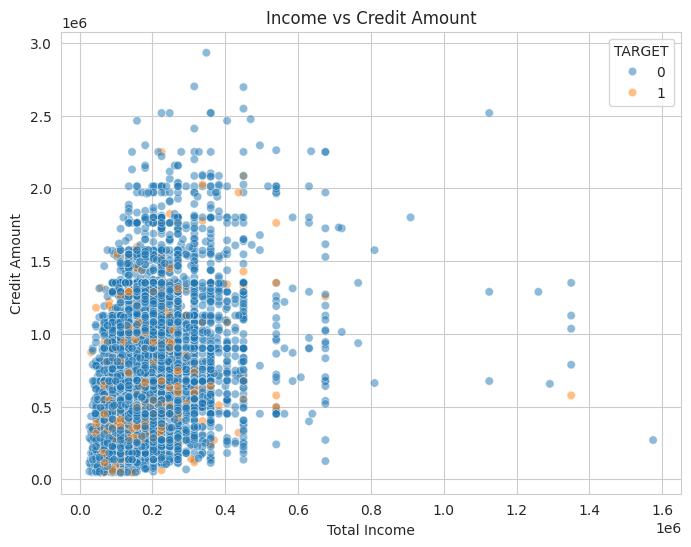

In [27]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x='AMT_INCOME_TOTAL',
    y='AMT_CREDIT',
    hue='TARGET',
    alpha=0.5
)

plt.title('Income vs Credit Amount')
plt.xlabel('Total Income')
plt.ylabel('Credit Amount')

plt.show()

In [28]:
corr, p_value = pearsonr(
    df['AMT_INCOME_TOTAL'].dropna(),
    df.loc[
        df['AMT_INCOME_TOTAL'].notna(),
        'AMT_CREDIT'
    ]
)

print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: 0.1568702718519311
P-value: 0.0


In [29]:
# Remove missing values
group_0 = df.loc[
    df['TARGET'] == 0,
    'AMT_INCOME_TOTAL'
].dropna()

group_1 = df.loc[
    df['TARGET'] == 1,
    'AMT_INCOME_TOTAL'
].dropna()

# Independent t-test
t_stat, p_value = ttest_ind(
    group_0,
    group_1,
    equal_var=False
)

print("Independent T-Test")
print("-------------------")
print("H0: Mean income is equal for TARGET 0 and TARGET 1")
print("H1: Mean income is different for TARGET 0 and TARGET 1")
print()
print("Mean Income - TARGET 0:", group_0.mean())
print("Mean Income - TARGET 1:", group_1.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject H0")
    print("Conclusion: The difference in mean income is statistically significant.")
else:
    print("\nResult: Fail to reject H0")
    print("Conclusion: The difference in mean income is not statistically significant.")

Independent T-Test
-------------------
H0: Mean income is equal for TARGET 0 and TARGET 1
H1: Mean income is different for TARGET 0 and TARGET 1

Mean Income - TARGET 0: 169077.72226581787
Mean Income - TARGET 1: 165611.76090634443
T-statistic: 0.7306653940270041
P-value: 0.464990427440257

Result: Fail to reject H0
Conclusion: The difference in mean income is not statistically significant.


In [30]:
group_0 = df.loc[
    df['TARGET'] == 0,
    'AMT_CREDIT'
].dropna()

group_1 = df.loc[
    df['TARGET'] == 1,
    'AMT_CREDIT'
].dropna()

t_stat, p_value = ttest_ind(
    group_0,
    group_1,
    equal_var=False
)

print("T-Test: AMT_CREDIT")
print("-------------------")

print("Mean Credit - TARGET 0:", group_0.mean())
print("Mean Credit - TARGET 1:", group_1.mean())

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Significant difference in mean credit amount.")
else:
    print("Conclusion: No statistically significant difference.")

T-Test: AMT_CREDIT
-------------------
Mean Credit - TARGET 0: 602648.2820019386
Mean Credit - TARGET 1: 557778.527673716
T-statistic: 19.273175042266935
P-value: 2.72191069717545e-82
Conclusion: Significant difference in mean credit amount.


In [31]:
test_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'CNT_CHILDREN',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

test_results = []

for feature in test_features:

    if feature not in df.columns:
        continue

    group_0 = df.loc[
        df['TARGET'] == 0,
        feature
    ].dropna()

    group_1 = df.loc[
        df['TARGET'] == 1,
        feature
    ].dropna()

    t_stat, p_value = ttest_ind(
        group_0,
        group_1,
        equal_var=False
    )

    test_results.append({
        'Feature': feature,
        'Mean TARGET 0': group_0.mean(),
        'Mean TARGET 1': group_1.mean(),
        'T-statistic': t_stat,
        'P-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

ttest_results = pd.DataFrame(test_results)

display(ttest_results)

,Feature,Mean TARGET 0,Mean TARGET 1,T-statistic,P-value,Significant
0,AMT_INCOME_TOTAL,169077.722266,165611.760906,0.730665,4.649904e-01,No
1,AMT_CREDIT,602648.282002,557778.527674,19.273175,2.721911e-82,Yes
2,AMT_ANNUITY,27163.623349,26481.744290,8.147334,3.857944e-16,Yes
3,AMT_GOODS_PRICE,542736.795003,488972.412554,25.601850,4.280023e-143,Yes
4,CNT_CHILDREN,0.412946,0.463807,-10.191429,2.381146e-24,Yes
5,DAYS_BIRTH,-16138.176397,-14884.828077,-45.006188,0.000000e+00,Yes
6,DAYS_EMPLOYED,65696.146123,42394.675448,28.962056,4.919699e-182,Yes
7,EXT_SOURCE_1,0.511461,0.386968,58.554994,0.000000e+00,Yes
8,EXT_SOURCE_2,0.523479,0.410935,80.465534,0.000000e+00,Yes
9,EXT_SOURCE_3,0.520969,0.390717,84.578411,0.000000e+00,Yes


In [32]:
# Create contingency table
contingency_table = pd.crosstab(
    df['CODE_GENDER'],
    df['TARGET']
)

print("Contingency Table:")
display(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nReject H0")
    print("There is a statistically significant association between gender and TARGET.")
else:
    print("\nFail to reject H0")
    print("There is no statistically significant association between gender and TARGET.")

Contingency Table:


TARGET,0,1
CODE_GENDER,,
F,188278,14170
M,94404,10655
XNA,4,0


Chi-Square Statistic: 920.7913340361749
Degrees of Freedom: 2
P-value: 1.1290217848908289e-200

Reject H0
There is a statistically significant association between gender and TARGET.


In [33]:
categorical_test_features = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_CONTRACT_TYPE',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE'
]

chi_results = []

for feature in categorical_test_features:

    if feature not in df.columns:
        continue

    table = pd.crosstab(
        df[feature],
        df['TARGET']
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        'Feature': feature,
        'Chi-square': chi2,
        'Degrees of Freedom': dof,
        'P-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_results_df = pd.DataFrame(chi_results)

display(chi_results_df)

,Feature,Chi-square,Degrees of Freedom,P-value,Significant
0,CODE_GENDER,920.791334,2,1.129022e-200,Yes
1,FLAG_OWN_CAR,146.656018,1,9.330994e-34,Yes
2,FLAG_OWN_REALTY,11.575827,1,6.681470e-04,Yes
3,NAME_CONTRACT_TYPE,293.150542,1,1.023515e-65,Yes
4,NAME_INCOME_TYPE,1253.470808,7,1.928146e-266,Yes
5,NAME_EDUCATION_TYPE,1019.213187,4,2.447681e-219,Yes
6,NAME_FAMILY_STATUS,504.694083,5,7.744842e-107,Yes
7,NAME_HOUSING_TYPE,420.556190,5,1.099089e-88,Yes


In [34]:
anova_data = []

for group in df['NAME_EDUCATION_TYPE'].dropna().unique():

    values = df.loc[
        df['NAME_EDUCATION_TYPE'] == group,
        'AMT_INCOME_TOTAL'
    ].dropna()

    if len(values) > 1:
        anova_data.append(values)

f_stat, p_value = f_oneway(*anova_data)

print("ANOVA Test")
print("----------")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nReject H0")
    print("At least one education group has a significantly different mean income.")
else:
    print("\nFail to reject H0")
    print("No significant difference in mean income was detected among education groups.")

ANOVA Test
----------
F-statistic: 753.2160079040974
P-value: 0.0

Reject H0
At least one education group has a significantly different mean income.


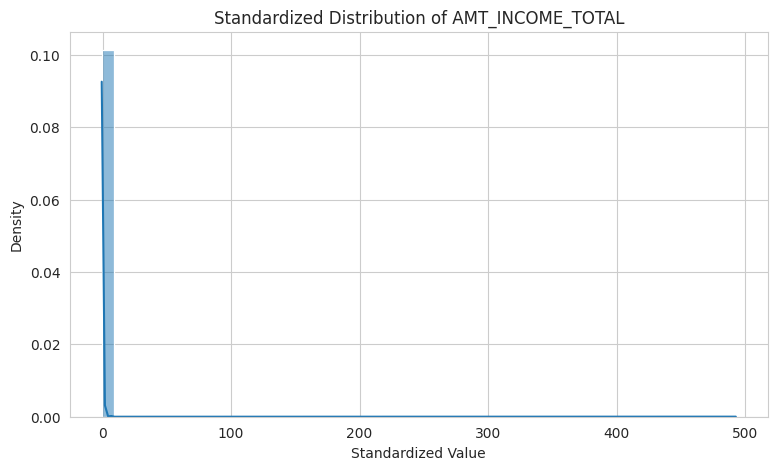

In [35]:
feature = 'AMT_INCOME_TOTAL'

data = df[feature].dropna()

# Standardize
z = (data - data.mean()) / data.std()

plt.figure(figsize=(9, 5))

sns.histplot(
    z,
    bins=50,
    kde=True,
    stat='density'
)

plt.title(f'Standardized Distribution of {feature}')
plt.xlabel('Standardized Value')
plt.ylabel('Density')

plt.show()

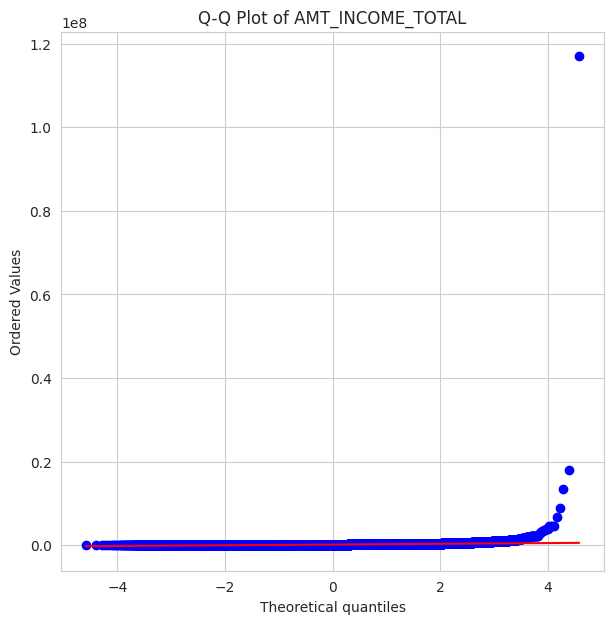

In [36]:
feature = 'AMT_INCOME_TOTAL'

data = df[feature].dropna()

plt.figure(figsize=(7, 7))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title(f'Q-Q Plot of {feature}')

plt.show()

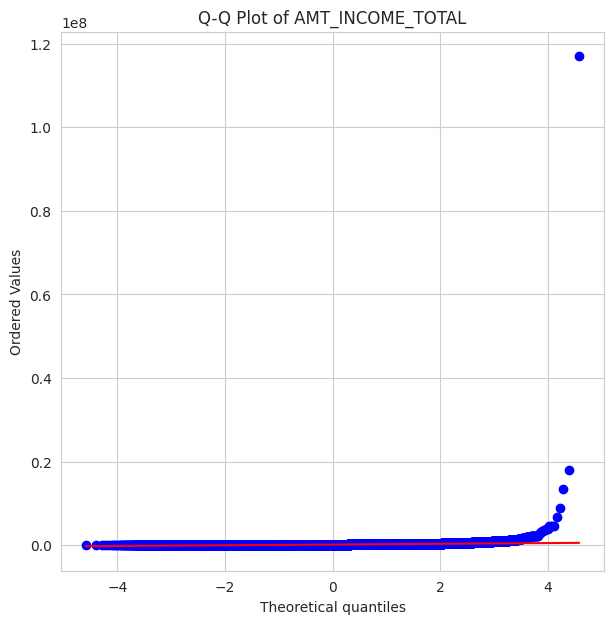

In [37]:
feature = 'AMT_INCOME_TOTAL'

data = df[feature].dropna()

plt.figure(figsize=(7, 7))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title(f'Q-Q Plot of {feature}')

plt.show()

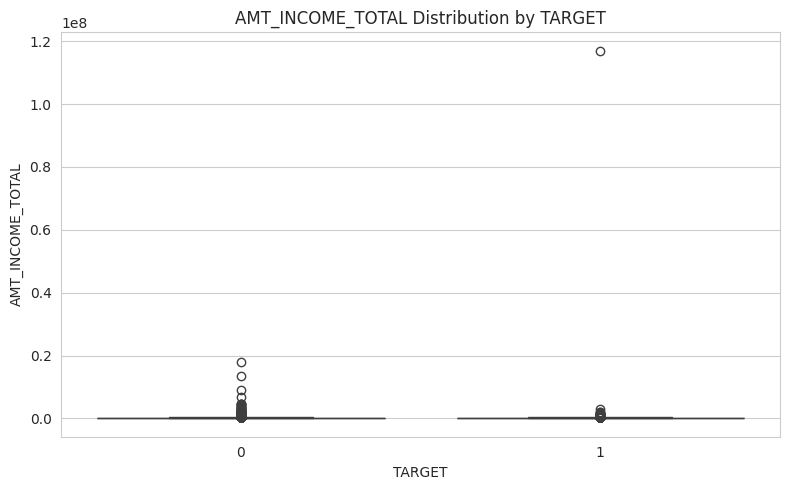

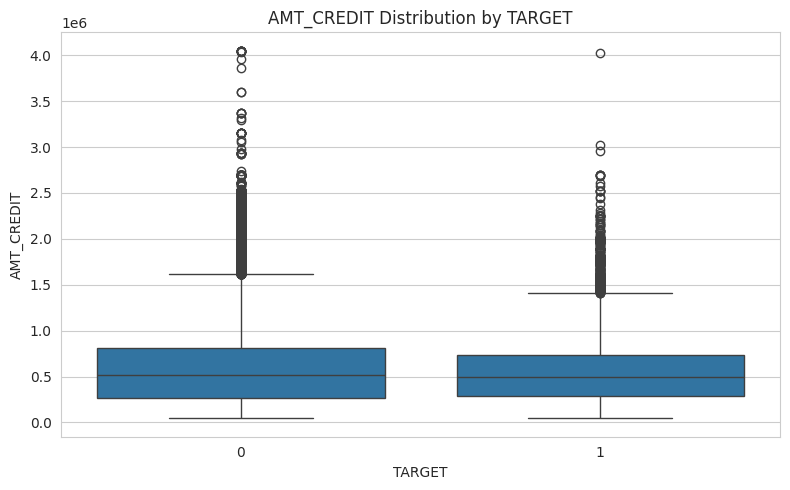

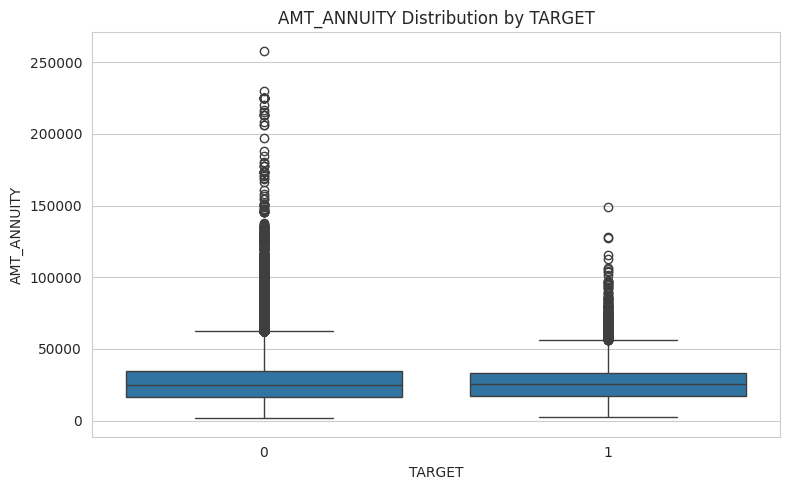

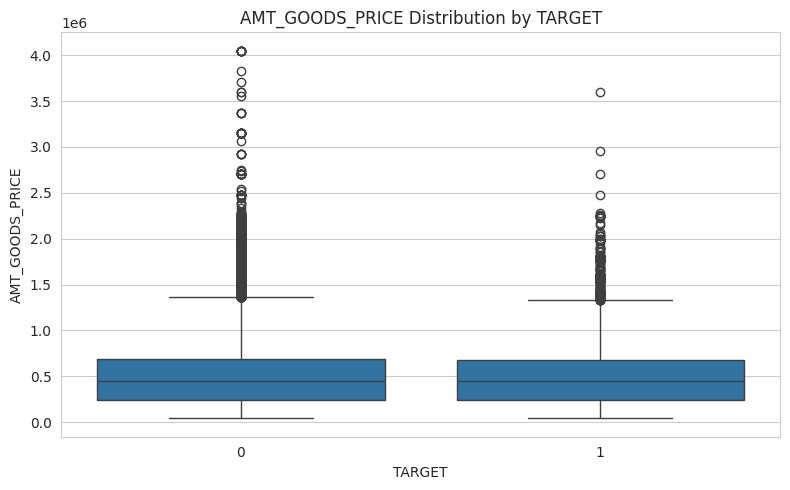

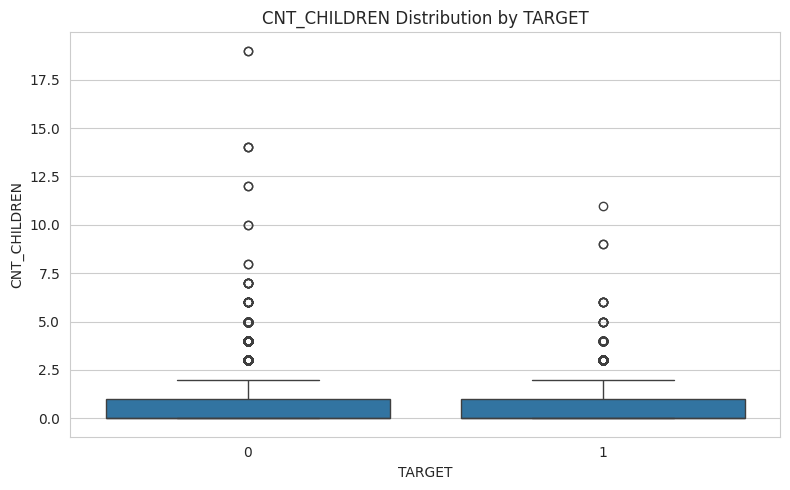

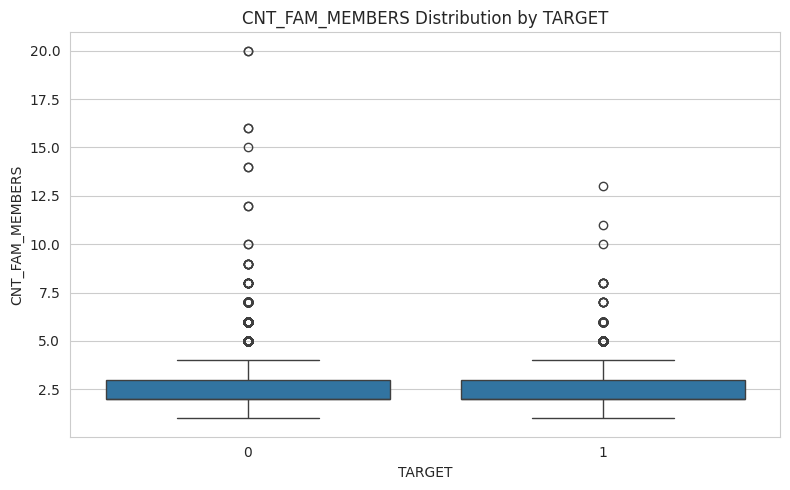

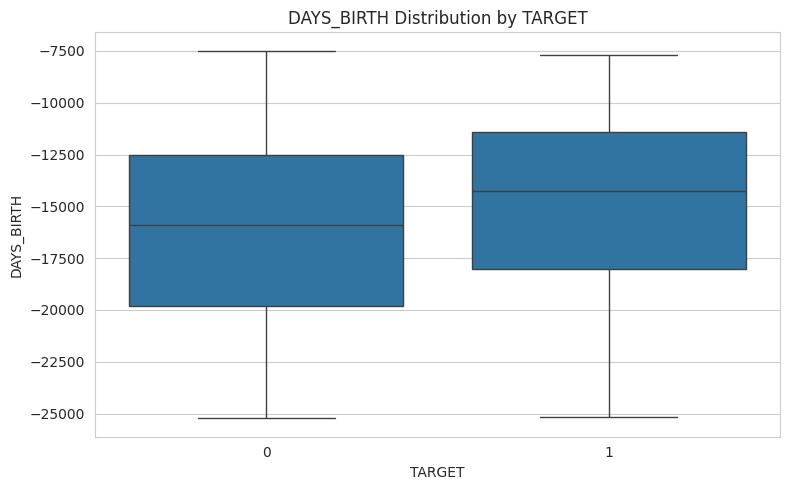

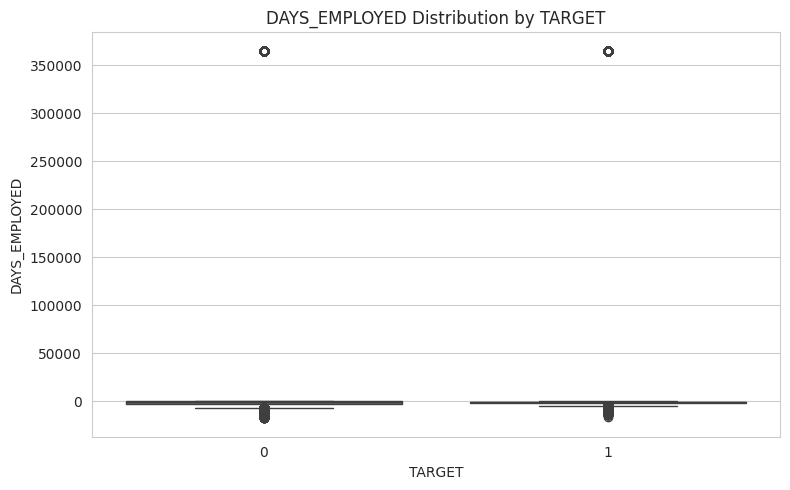

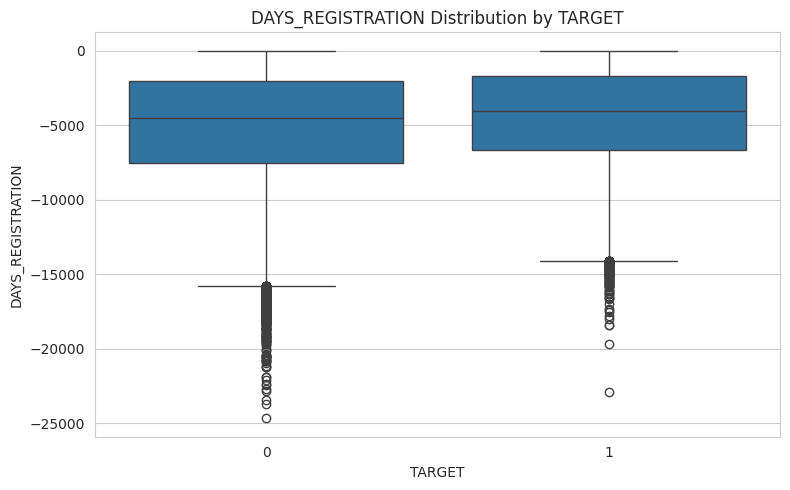

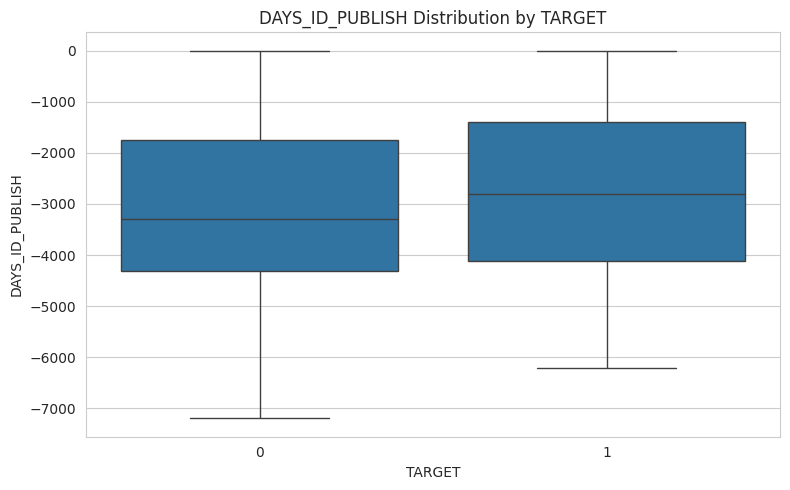

In [38]:
for col in important_numerical[:10]:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='TARGET',
        y=col
    )

    plt.title(f'{col} Distribution by TARGET')
    plt.xlabel('TARGET')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

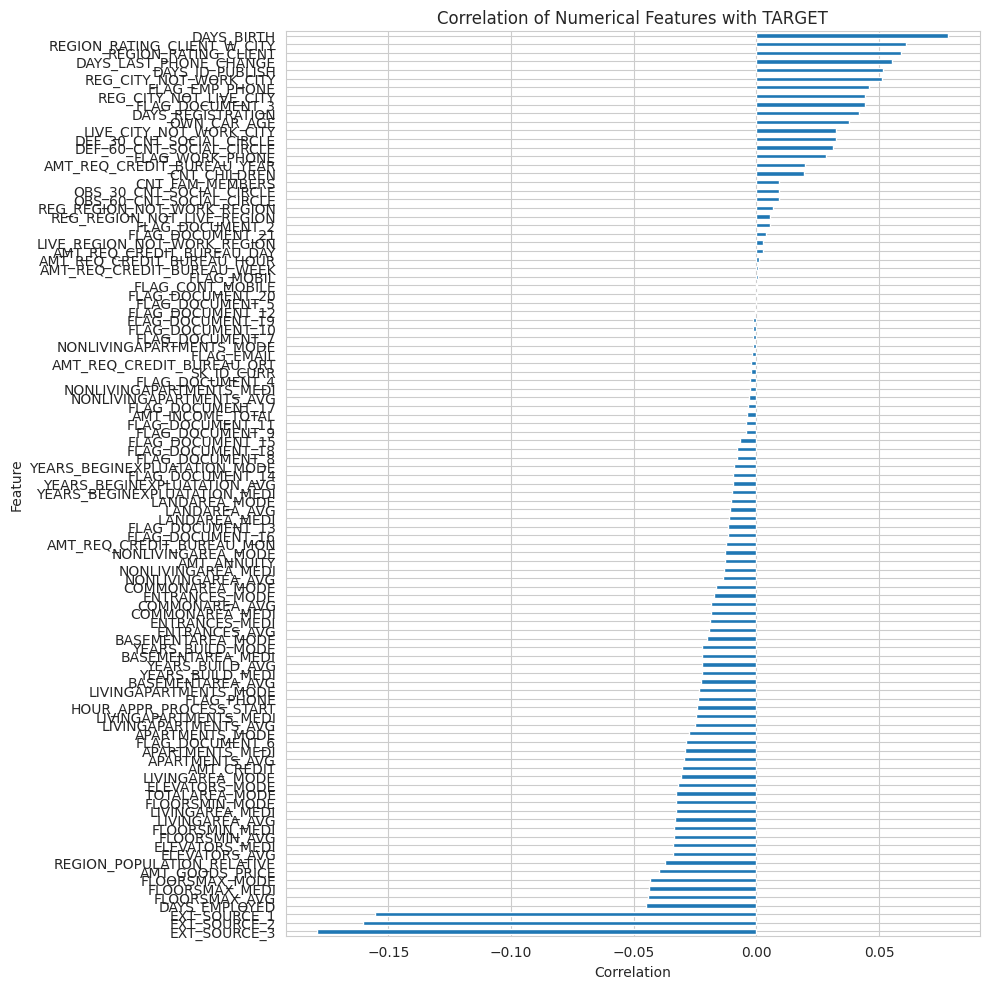

In [39]:
target_correlation = (
    df[numerical_features]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

plt.figure(figsize=(10, 10))

target_correlation.plot(
    kind='barh'
)

plt.title('Correlation of Numerical Features with TARGET')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [40]:
print("Top Positive Correlations with TARGET:")
display(
    target_correlation
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Negative Correlations with TARGET:")
display(
    target_correlation
    .sort_values()
    .head(10)
)

Top Positive Correlations with TARGET:


,TARGET
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982
REG_CITY_NOT_LIVE_CITY,0.044395
FLAG_DOCUMENT_3,0.044346
DAYS_REGISTRATION,0.041975



Top Negative Correlations with TARGET:


,TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_EMPLOYED,-0.044932
FLOORSMAX_AVG,-0.044003
FLOORSMAX_MEDI,-0.043768
FLOORSMAX_MODE,-0.043226
AMT_GOODS_PRICE,-0.039645
REGION_POPULATION_RELATIVE,-0.037227
ELEVATORS_AVG,-0.034199


In [41]:
print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print("\n1. DATASET SIZE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n2. DUPLICATES")
print("Duplicate rows:", df.duplicated().sum())

print("\n3. TARGET DISTRIBUTION")
print(df['TARGET'].value_counts())

print("\nTarget Percentage:")
print(
    (df['TARGET'].value_counts(normalize=True) * 100).round(2)
)

print("\n4. NUMERICAL FEATURES")
print("Number:", len(numerical_features))

print("\n5. CATEGORICAL FEATURES")
print("Number:", len(categorical_features))

print("\n6. FEATURES WITH MOST MISSING VALUES")
display(
    missing_df.head(10)
)

print("\n7. FEATURES MOST CORRELATED WITH TARGET")
display(
    target_correlation.abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\n8. MOST SKEWED FEATURES")
display(
    skew_df.head(10)
)

print("\n9. FEATURES WITH MOST OUTLIERS")
display(
    outlier_df
    .sort_values(
        'Outlier Percentage',
        ascending=False
    )
    .head(10)
)

EDA SUMMARY

1. DATASET SIZE
Rows: 307511
Columns: 122

2. DUPLICATES
Duplicate rows: 0

3. TARGET DISTRIBUTION
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

4. NUMERICAL FEATURES
Number: 106

5. CATEGORICAL FEATURES
Number: 16

6. FEATURES WITH MOST MISSING VALUES


,Column,Missing Values,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953



7. FEATURES MOST CORRELATED WITH TARGET


,TARGET
EXT_SOURCE_3,0.178919
EXT_SOURCE_2,0.160472
EXT_SOURCE_1,0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982



8. MOST SKEWED FEATURES


,Feature,Skewness
0,AMT_INCOME_TOTAL,391.559654
11,OWN_CAR_AGE,2.745422
4,CNT_CHILDREN,1.974604
7,DAYS_EMPLOYED,1.664346
2,AMT_ANNUITY,1.579777
10,REGION_POPULATION_RELATIVE,1.488009
3,AMT_GOODS_PRICE,1.349000
1,AMT_CREDIT,1.234778
5,CNT_FAM_MEMBERS,0.987543
9,DAYS_ID_PUBLISH,0.349327



9. FEATURES WITH MOST OUTLIERS


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
7,DAYS_EMPLOYED,-2760.000000,-289.000000,2471.000000,-6466.50000,3.417500e+03,72217,23.484363
3,AMT_GOODS_PRICE,238500.000000,679500.000000,441000.000000,-423000.00000,1.341000e+06,14728,4.793756
11,OWN_CAR_AGE,5.000000,15.000000,10.000000,-10.00000,3.000000e+01,4932,4.715917
0,AMT_INCOME_TOTAL,112500.000000,202500.000000,90000.000000,-22500.00000,3.375000e+05,14035,4.564064
10,REGION_POPULATION_RELATIVE,0.010006,0.028663,0.018657,-0.01798,5.664850e-02,8412,2.735512
2,AMT_ANNUITY,16524.000000,34596.000000,18072.000000,-10584.00000,6.170400e+04,7504,2.440333
1,AMT_CREDIT,270000.000000,808650.000000,538650.000000,-537975.00000,1.616625e+06,6562,2.133907
4,CNT_CHILDREN,0.000000,1.000000,1.000000,-1.50000,2.500000e+00,4272,1.389219
5,CNT_FAM_MEMBERS,2.000000,3.000000,1.000000,0.50000,4.500000e+00,4007,1.303051
8,DAYS_REGISTRATION,-7479.500000,-2010.000000,5469.500000,-15683.75000,6.194250e+03,659,0.214301


In [42]:
print("=" * 70)
print("HYPOTHESIS TEST SUMMARY")
print("=" * 70)

print("\nT-TEST RESULTS")
display(ttest_results)

print("\nCHI-SQUARE RESULTS")
display(chi_results_df)

HYPOTHESIS TEST SUMMARY

T-TEST RESULTS


,Feature,Mean TARGET 0,Mean TARGET 1,T-statistic,P-value,Significant
0,AMT_INCOME_TOTAL,169077.722266,165611.760906,0.730665,4.649904e-01,No
1,AMT_CREDIT,602648.282002,557778.527674,19.273175,2.721911e-82,Yes
2,AMT_ANNUITY,27163.623349,26481.744290,8.147334,3.857944e-16,Yes
3,AMT_GOODS_PRICE,542736.795003,488972.412554,25.601850,4.280023e-143,Yes
4,CNT_CHILDREN,0.412946,0.463807,-10.191429,2.381146e-24,Yes
5,DAYS_BIRTH,-16138.176397,-14884.828077,-45.006188,0.000000e+00,Yes
6,DAYS_EMPLOYED,65696.146123,42394.675448,28.962056,4.919699e-182,Yes
7,EXT_SOURCE_1,0.511461,0.386968,58.554994,0.000000e+00,Yes
8,EXT_SOURCE_2,0.523479,0.410935,80.465534,0.000000e+00,Yes
9,EXT_SOURCE_3,0.520969,0.390717,84.578411,0.000000e+00,Yes



CHI-SQUARE RESULTS


,Feature,Chi-square,Degrees of Freedom,P-value,Significant
0,CODE_GENDER,920.791334,2,1.129022e-200,Yes
1,FLAG_OWN_CAR,146.656018,1,9.330994e-34,Yes
2,FLAG_OWN_REALTY,11.575827,1,6.681470e-04,Yes
3,NAME_CONTRACT_TYPE,293.150542,1,1.023515e-65,Yes
4,NAME_INCOME_TYPE,1253.470808,7,1.928146e-266,Yes
5,NAME_EDUCATION_TYPE,1019.213187,4,2.447681e-219,Yes
6,NAME_FAMILY_STATUS,504.694083,5,7.744842e-107,Yes
7,NAME_HOUSING_TYPE,420.556190,5,1.099089e-88,Yes
